Implied correlation from corrected Lambda:
[[ 1.    -0.326 -0.291 -0.045 -0.081  0.623 -0.148]
 [-0.326  1.     0.553  0.028  0.216 -0.369  0.269]
 [-0.291  0.553  1.     0.018  0.127 -0.259  0.21 ]
 [-0.045  0.028  0.018  1.    -0.021 -0.05   0.002]
 [-0.081  0.216  0.127 -0.021  1.    -0.091  0.142]
 [ 0.623 -0.369 -0.259 -0.05  -0.091  1.    -0.18 ]
 [-0.148  0.269  0.21   0.002  0.142 -0.18   1.   ]]
=== LOADINGS COMPARISON ===

Target (Lambda_corrected):
                  F0      F1      F2      F3      F4      F5      F6
gurkor       -0.7132  0.4546  0.2253 -0.2034 -0.0390 -0.2406  0.3650
guitars       0.7653  0.2235  0.0959 -0.2423 -0.2169 -0.4594 -0.1957
slingshots    0.6830  0.2158  0.0961 -0.4528 -0.3190  0.3763  0.1714
stocks        0.0695 -0.4008  0.9100  0.0791 -0.0049  0.0099 -0.0006
sugar         0.3139  0.5663  0.1385  0.7136 -0.2158  0.0728  0.0231
water        -0.7278  0.4291  0.2059 -0.2206 -0.0919  0.1714 -0.3965
tranquillity  0.4515  0.3726  0.1434 -0.0895  0.7911 

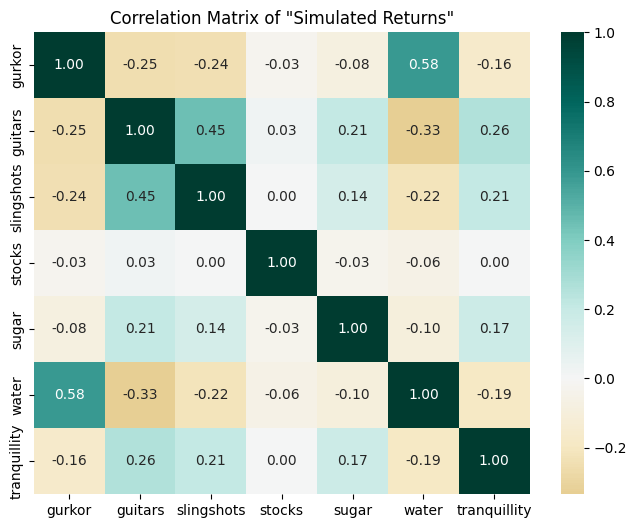

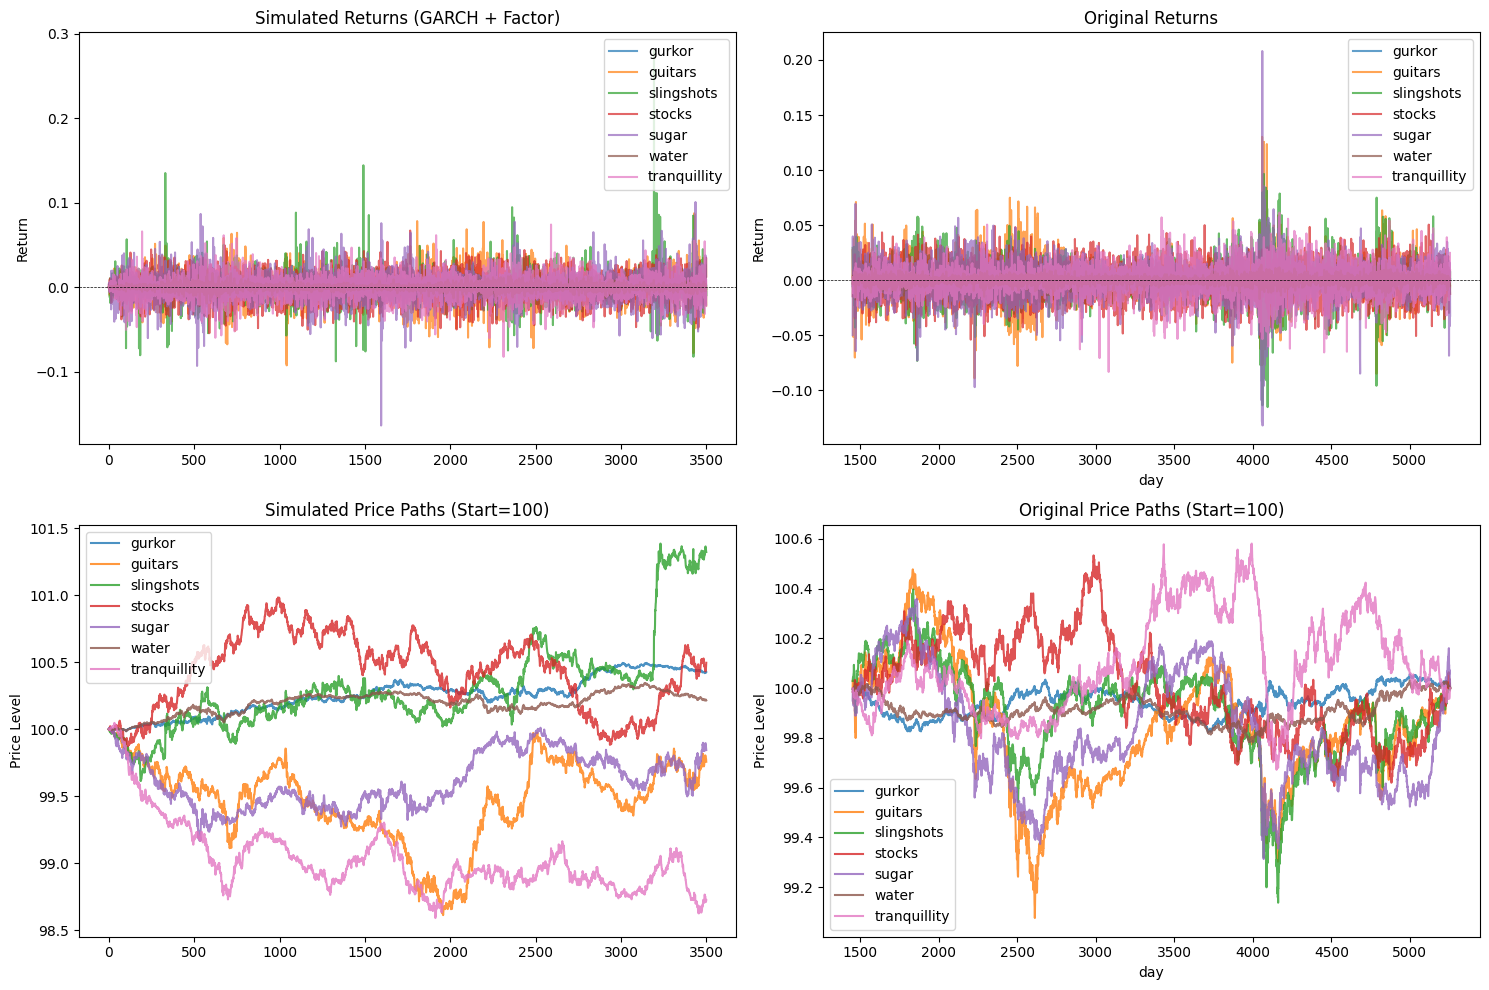


Volatility comparison (Original vs Simulated):
              Original  Simulated  Ratio
gurkor          0.0041     0.0041    1.0
guitars         0.0160     0.0160    1.0
slingshots      0.0164     0.0164    1.0
stocks          0.0149     0.0149    1.0
sugar           0.0158     0.0158    1.0
water           0.0035     0.0035    1.0
tranquillity    0.0133     0.0133    1.0

Correlation matrix (Original):
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.326      -0.291  -0.045 -0.081  0.623        -0.148
guitars       -0.326    1.000       0.553   0.028  0.216 -0.369         0.269
slingshots    -0.291    0.553       1.000   0.018  0.127 -0.259         0.210
stocks        -0.045    0.028       0.018   1.000 -0.021 -0.050         0.002
sugar         -0.081    0.216       0.127  -0.021  1.000 -0.091         0.142
water          0.623   -0.369      -0.259  -0.050 -0.091  1.000        -0.180
tranquillity  -0.148    0.269       0.210   0.

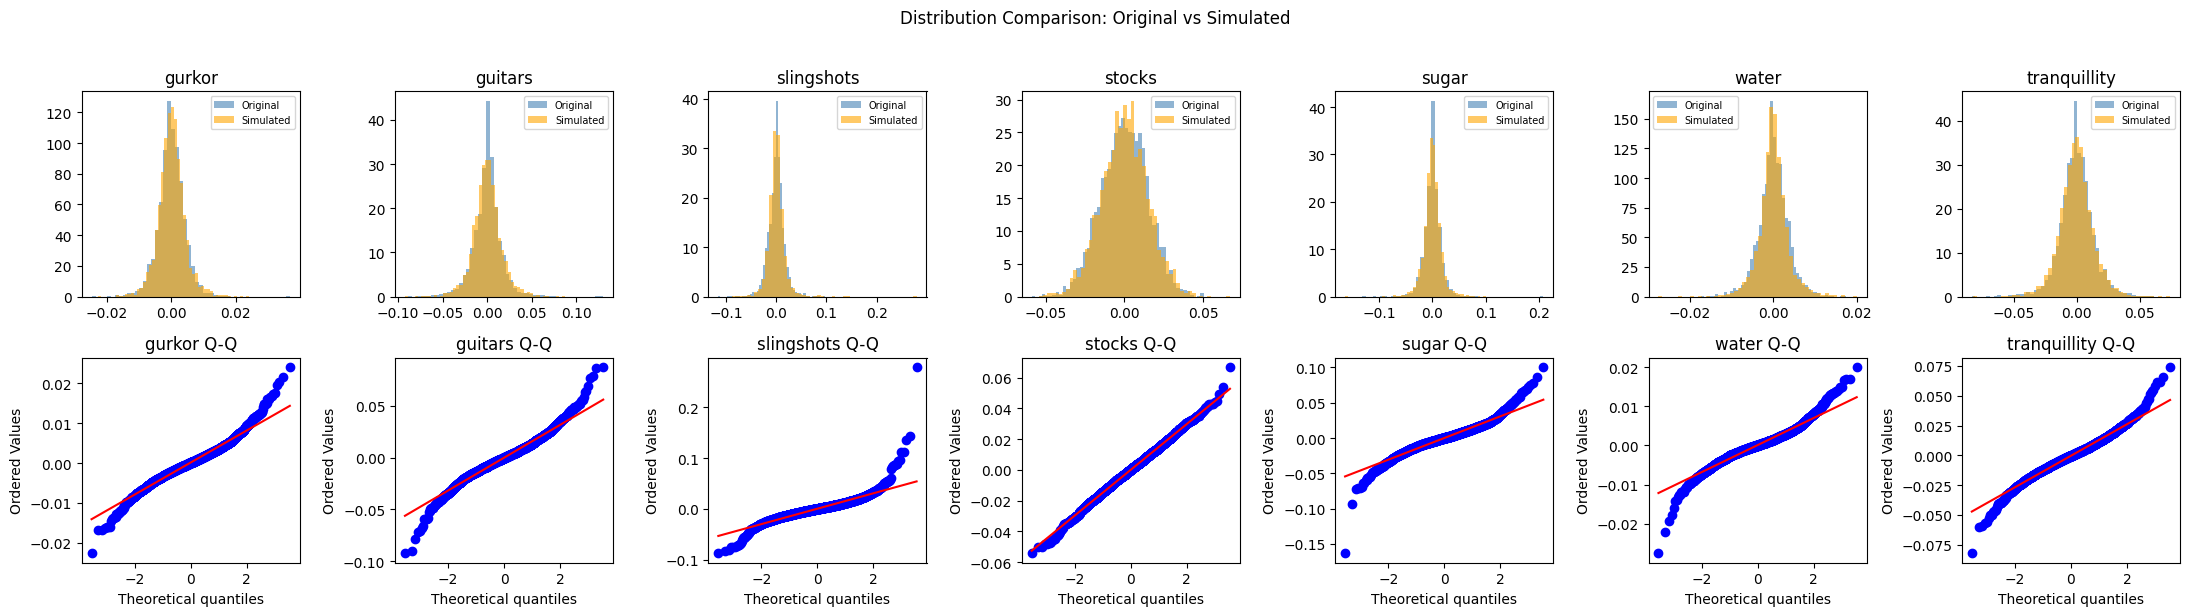

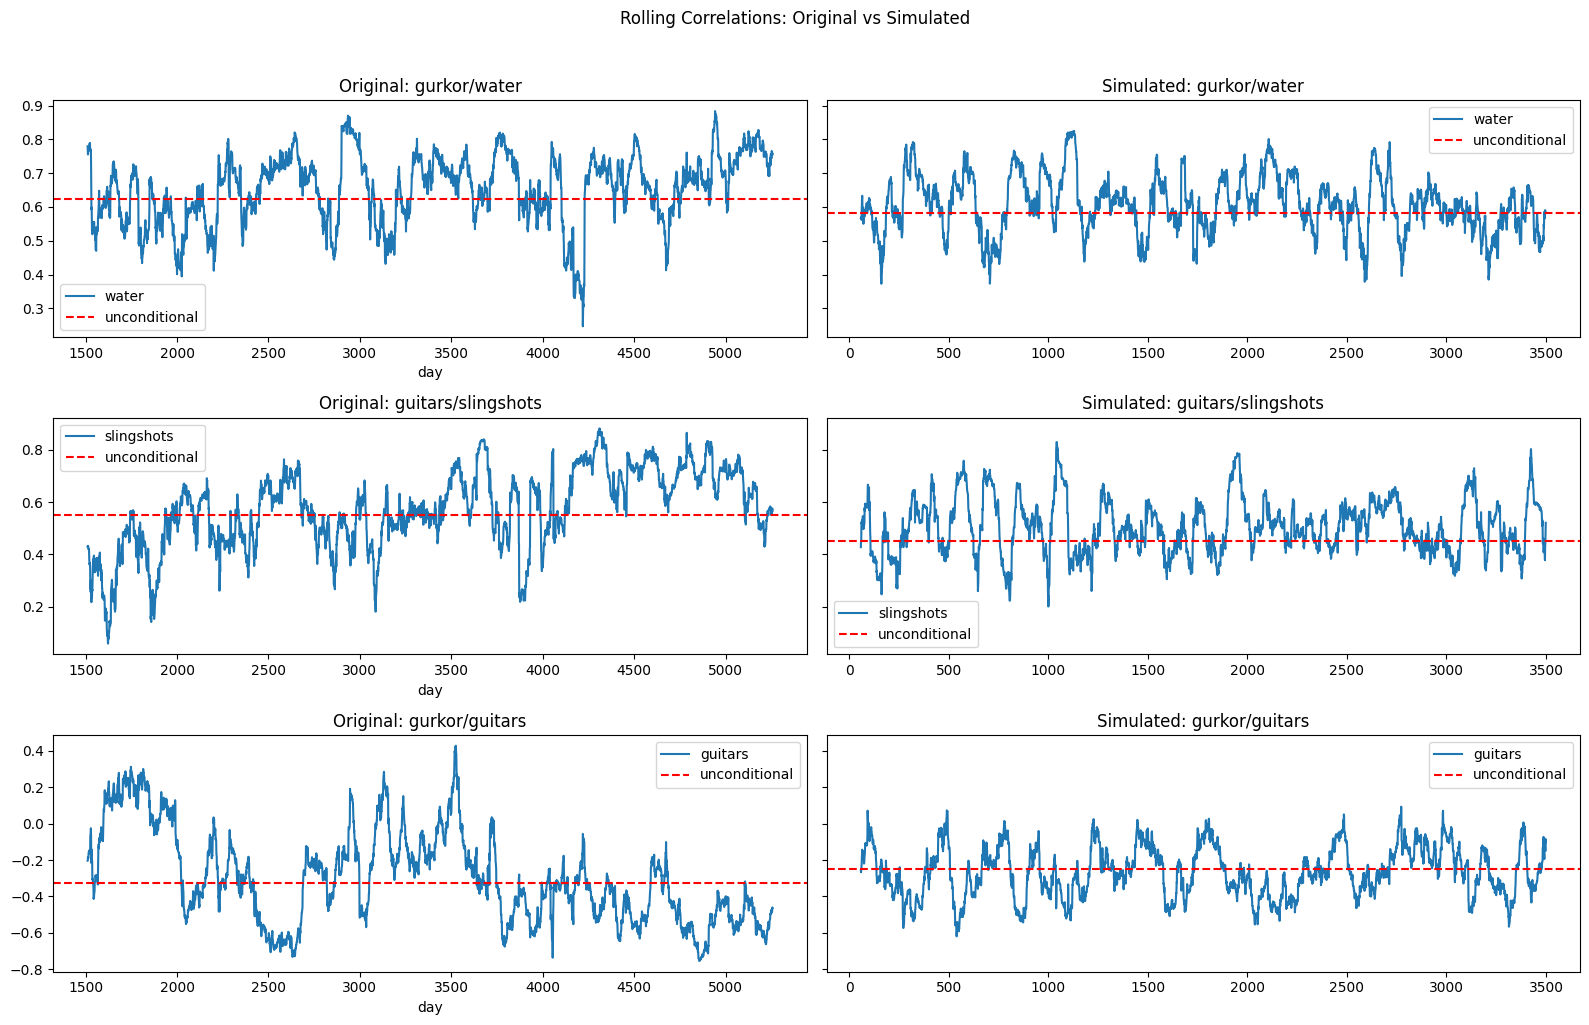

In [29]:

import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns

THEME = 'BrBG'



df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]

df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

# Calculate returns (price ratios Pt/Pt-1) as you did originally
df_og_returns = (df_original / df_original.shift(1) - 1).dropna() 
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean
original_stds = df_og_returns.std()


# -------------------------------------------------
# 1. Your original parameters
# -------------------------------------------------
var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# Factor loadings (7 observed x 7 latents)
Lambda_true = np.array([
    [-0.460493,  0.431975,  0.226305, -0.218470, -0.041653,  0.360676, -0.608752], # gurkor
    [ 0.494112,  0.212170,  0.095774, -0.260540, -0.236640,  0.685579,  0.328278], # guitars
    [ 0.441043,  0.204170,  0.094476, -0.485899, -0.347878, -0.561128, -0.287903], # slingshots
    [ 0.045350, -0.378985,  0.920457,  0.082476, -0.006300, -0.015188,  0.000779], # stocks
    [ 0.203079,  0.539617,  0.140728,  0.759331, -0.240474, -0.108821, -0.038918], # sugar
    [-0.469721,  0.408214,  0.206995, -0.237389, -0.099435, -0.257841,  0.661177], # water
    [ 0.292140,  0.353894,  0.144209, -0.092477,  0.868040, -0.080467,  0.009864]  # tranquillity
])

# VAR(2) coefficients (5 x 5)
# VAR(2) Lag 1 coefficients (7x7)
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557], # F0 eq
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590], # F1 eq
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809], # F2 eq
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002], # F3 eq
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988], # F4 eq
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336], # F5 eq
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]  # F6 eq
])

# VAR(2) Lag 2 coefficients (7x7)
Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700], # F0 eq
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445], # F1 eq
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037], # F2 eq
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329], # F3 eq
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718], # F4 eq
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123], # F5 eq
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]  # F6 eq
])

# Pruned VAR(2) Lag 1 coefficients (7x7)
# Removed: F0->F1, F1->F1, F2->F1, F4->F1, F2->F2, F4->F2, etc.
# Phi1 = np.array([
#     [ 0.066837,  0.000000,  0.000000, -0.129388, -0.120289, -0.162173,  0.000000], # F0 eq
#     [ 0.123793,  0.000000,  0.033206, -0.265276, -0.075745,  0.000000, -0.058590], # F1 eq
#     [ 0.026951,  0.000000,  0.000000, -0.045200,  0.000000,  0.000000,  0.000000], # F2 eq
#     [ 0.199106,  0.000000,  0.000000, -0.220926, -0.061257,  0.000000,  0.000000], # F3 eq
#     [-0.032751, -0.034423,  0.000000,  0.000000,  0.000000, -0.075896,  0.000000], # F4 eq
#     [ 0.016032,  0.000000,  0.000000, -0.033598, -0.052375, -0.296606,  0.000000], # F5 eq
#     [-0.014400,  0.000000,  0.021113, -0.040414,  0.000000,  0.035195, -0.182736]  # F6 eq
# ])

# # Pruned VAR(2) Lag 2 coefficients (7x7)
# Phi2 = np.array([
#     [ 0.000000,  0.000000,  0.000000, -0.076605,  0.000000, -0.084637,  0.000000], # F0 eq
#     [ 0.040158, -0.042788,  0.000000, -0.044778,  0.000000,  0.000000,  0.000000], # F1 eq
#     [ 0.000000,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000], # F2 eq
#     [ 0.000000,  0.000000,  0.000000, -0.047150,  0.031045,  0.000000, -0.054329], # F3 eq
#     [ 0.000000,  0.028481,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000], # F4 eq
#     [ 0.000000,  0.000000,  0.000000,  0.000000,  0.000000, -0.070937,  0.000000], # F5 eq
#     [ 0.000000,  0.034619,  0.000000,  0.000000,  0.000000,  0.000000, -0.061284]  # F6 eq
# ])

garch_params_obs = {
    "gurkor": {
        "alpha": 0.0354,
        "omega": 0.0600,
        "beta": 0.9610,
        "persistence": 0.9965
    },
    "guitars": {
        "alpha": 0.0825,
        "omega": 2.3800,
        "beta": 0.9076,
        "persistence": 0.9901
    },
    "slingshots": {
        "alpha": 0.0866,
        "omega": 5.1221,
        "beta": 0.8897,
        "persistence": 0.9763
    },
    "stocks": {
        "alpha": 0.0000,
        "omega": 4.7448,
        "beta": 0.9787,
        "persistence": 0.9787
    },
    "sugar": {
        "alpha": 0.0844,
        "omega": 3.9366,
        "beta": 0.9000,
        "persistence": 0.9844
    },
    "water": {
        "alpha": 0.0320,
        "omega": 0.0581,
        "beta": 0.9632,
        "persistence": 0.9952
    },
    "tranquillity": {
        "alpha": 0.0403,
        "omega": 1.0458,
        "beta": 0.9545,
        "persistence": 0.9948
    }
}

from numpy.linalg import eigh

og_corr = df_og_returns.corr().values  # 7x7

# Eigendecomposition of the correlation matrix
eigenvalues, eigenvectors = eigh(og_corr)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Lambda that reproduces correlations: Λ @ Λ.T = Σ
# Each column scaled by sqrt(eigenvalue)
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)

print("Implied correlation from corrected Lambda:")
print(np.round(Lambda_corrected @ Lambda_corrected.T, 3))


np.random.seed(42)
T = 4000
burn = 500

# -------------------------------------------------
# 1. Simulate factors with VAR(2) + Gaussian innovations
#    (GARCH handled at observed level, not factor level)
# -------------------------------------------------
F_sim = np.zeros((T, 7))

for t in range(2, T):
    F_sim[t] = Phi1 @ F_sim[t-1] + Phi2 @ F_sim[t-2] + np.random.randn(7)

F_sim = F_sim[burn:]

# -------------------------------------------------
# 2. Map to observed space via corrected loadings
# -------------------------------------------------
Y_sim = F_sim @ Lambda_corrected.T  # (T x 7) — correct correlations, no vol clustering yet

# Standardize to unit variance before applying GARCH
Y_sim_std = Y_sim / Y_sim.std(axis=0)

Z = Y_sim_std 
# -------------------------------------------------
# 3. Apply GARCH(1,1) volatility at observed series level
#    Uses garch_params_obs fitted on original observed returns
# -------------------------------------------------
from scipy.stats import norm, t as student_t

# Store nu per asset from GARCH residual fitting
nu_obs = {
    'gurkor': 21.72, 'guitars': 18.53, 'slingshots': 32.79,
    'stocks': 401.88, 'sugar': 17.69, 'water': 22.65, 'tranquillity': 16.41
}

nu_target = {
    'gurkor': 5.66, 'guitars': 5.04, 'slingshots': 5.28,
    'stocks': 132.55, 'sugar': 4.45, 'water': 7.65, 'tranquillity': 6.31
}

# Simple midpoint — tune alpha between 0 and 1
# alpha=0 -> nu_obs (too low kurtosis)
# alpha=1 -> nu_target (too high kurtosis)
# Start with 0.5, then adjust per asset based on over/undershoot
alpha_blend = {
    'gurkor':       0.85,   # overshot 5.69 vs 3.62 — back off
    'guitars':      0.727,   # overshot badly 11.38 vs 5.75
    'slingshots':   1.034,   # undershot slightly 3.65 vs 4.70
    'stocks':       0.8,   # fine either way, nearly Gaussian
    'sugar':        0.973,   # overshot 16.17 vs 13.47 — back off slightly
    'water':        0.93,   # close, slight overshoot
    'tranquillity': 0.77,   # overshot 3.97 vs 2.59
}

nu_blended = {
    col: nu_obs[col] + alpha_blend[col] * (nu_target[col] - nu_obs[col])
    for col in var_names
}

# Precompute scaling factors
t_scales = {
    col: 1.0 / np.sqrt(nu_blended[col] / (nu_blended[col] - 2))
    for col in var_names
}

Y_final = np.zeros_like(Y_sim)
h_obs = np.ones((len(Y_sim), 7))

for t in range(1, len(Y_sim)):
    for i, col in enumerate(var_names):
        p = garch_params_obs[col]
        h_obs[t, i] = (p['omega'] +
                       p['alpha'] * Y_final[t-1, i]**2 +
                       p['beta'] * h_obs[t-1, i])

    uniform = norm.cdf(Z[t])
    correlated_t = np.array([
        student_t.ppf(uniform[i], df=nu_blended[col]) * t_scales[col]
        for i, col in enumerate(var_names)
    ])

    Y_final[t] = correlated_t * np.sqrt(h_obs[t])
# Rescale to match original volatility
df_returns_final = pd.DataFrame(Y_final, columns=var_names)
df_returns_final = df_returns_final.multiply(
    original_stds / df_returns_final.std(), axis=1
)

# -------------------------------------------------
# 4. Procrustes alignment (verify factor recovery)
# -------------------------------------------------
pca = PCA(n_components=7)
F_est = pca.fit_transform(df_returns_final)
Lambda_est = pca.components_.T

R, _ = orthogonal_procrustes(F_est, F_sim)
F_aligned = F_est @ R
Lambda_aligned = Lambda_est @ R

signs = np.sign(np.diag(Lambda_aligned.T @ Lambda_corrected))
Lambda_aligned = Lambda_aligned * signs
F_aligned = F_aligned * signs

# -------------------------------------------------
# 5. Validation
# -------------------------------------------------
print("=== LOADINGS COMPARISON ===")
print("\nTarget (Lambda_corrected):")
print(pd.DataFrame(Lambda_corrected, index=var_names,
                   columns=[f"F{i}" for i in range(7)]).round(4))
print("\nAligned Simulated Loadings:")
print(pd.DataFrame(np.round(Lambda_aligned, 4), index=var_names,
                   columns=[f"F{i}" for i in range(7)]))

print("\nCorrelation between true and aligned factors:")
print(np.diag(np.corrcoef(F_sim.T, F_aligned.T)[:7, 7:]).round(4))

print("\n=== RETURN PROPERTIES ===")
print("\nCorrelation matrix (Original vs Simulated):")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))

print("\nKurtosis comparison:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\nGARCH persistence on simulated series:")
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000,
                     vol='Garch', p=1, q=1).fit(disp='off')
    p_sim = res.params['alpha[1]'] + res.params['beta[1]']
    p_og = garch_params_obs[col]['persistence']
    print(f"  {col}: simulated={p_sim:.4f}, original={p_og:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(df_returns_final.corr(), annot=True, cmap=THEME, center=0, fmt=".2f")
plt.title('Correlation Matrix of "Simulated Returns"')
plt.show()
# -------------------------------------------------
# 6. Accumulate to price series (start at 100)
# -------------------------------------------------
start_value = 100
df_prices_sim = start_value + df_returns_final.cumsum()
df_prices_original = start_value + df_og_returns.cumsum()

# -------------------------------------------------
# 7. Plot comparison
# -------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df_returns_final.plot(ax=axes[0,0], alpha=0.7, title='Simulated Returns (GARCH + Factor)')
axes[0,0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0,0].set_ylabel('Return')

df_og_returns.plot(ax=axes[0,1], alpha=0.7, title='Original Returns')
axes[0,1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0,1].set_ylabel('Return')

df_prices_sim.plot(ax=axes[1,0], alpha=0.8, title='Simulated Price Paths (Start=100)')
axes[1,0].set_ylabel('Price Level')

df_prices_original.plot(ax=axes[1,1], alpha=0.8, title='Original Price Paths (Start=100)')
axes[1,1].set_ylabel('Price Level')

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 8. Validation: Volatility + correlation + kurtosis
# -------------------------------------------------
print("\nVolatility comparison (Original vs Simulated):")
print(pd.DataFrame({
    'Original': original_stds,
    'Simulated': df_returns_final.std(),
    'Ratio': df_returns_final.std() / original_stds
}).round(4))

print("\nCorrelation matrix (Original):")
print(df_og_returns.corr().round(3))
print("\nCorrelation matrix (Simulated):")
print(df_returns_final.corr().round(3))

print("\nKurtosis comparison:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

# -------------------------------------------------
# 9. Distribution plot
# -------------------------------------------------
from scipy import stats

fig, axes = plt.subplots(2, 7, figsize=(22, 6))
for i, col in enumerate(var_names):
    axes[0, i].hist(df_og_returns[col], bins=50, alpha=0.6, 
                    label='Original', color='steelblue', density=True)
    axes[0, i].hist(df_returns_final[col], bins=50, alpha=0.6, 
                    label='Simulated', color='orange', density=True)
    axes[0, i].set_title(col)
    axes[0, i].legend(fontsize=7)

    stats.probplot(df_returns_final[col], plot=axes[1, i])
    axes[1, i].set_title(f'{col} Q-Q')

plt.suptitle('Distribution Comparison: Original vs Simulated', y=1.02)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 10. Rolling correlation comparison (key pairs)
# -------------------------------------------------
window = 60
pairs = [('gurkor', 'water'), ('guitars', 'slingshots'), ('gurkor', 'guitars')]

fig, axes = plt.subplots(len(pairs), 2, figsize=(16, 10), sharey='row')

for i, (a, b) in enumerate(pairs):
    df_og_returns[[a,b]].rolling(window).corr().unstack()[a][b].plot(
        ax=axes[i,0], title=f'Original: {a}/{b}')
    axes[i,0].axhline(df_og_returns[[a,b]].corr().iloc[0,1], 
                      color='red', linestyle='--', label='unconditional')
    axes[i,0].legend()

    df_returns_final[[a,b]].rolling(window).corr().unstack()[a][b].plot(
        ax=axes[i,1], title=f'Simulated: {a}/{b}')
    axes[i,1].axhline(df_returns_final[[a,b]].corr().iloc[0,1],
                      color='red', linestyle='--', label='unconditional')
    axes[i,1].legend()

plt.suptitle('Rolling Correlations: Original vs Simulated', y=1.02)
plt.tight_layout()
plt.show()

FINAL MODEL VALIDATION
CONDITIONAL VOL CORRELATION:


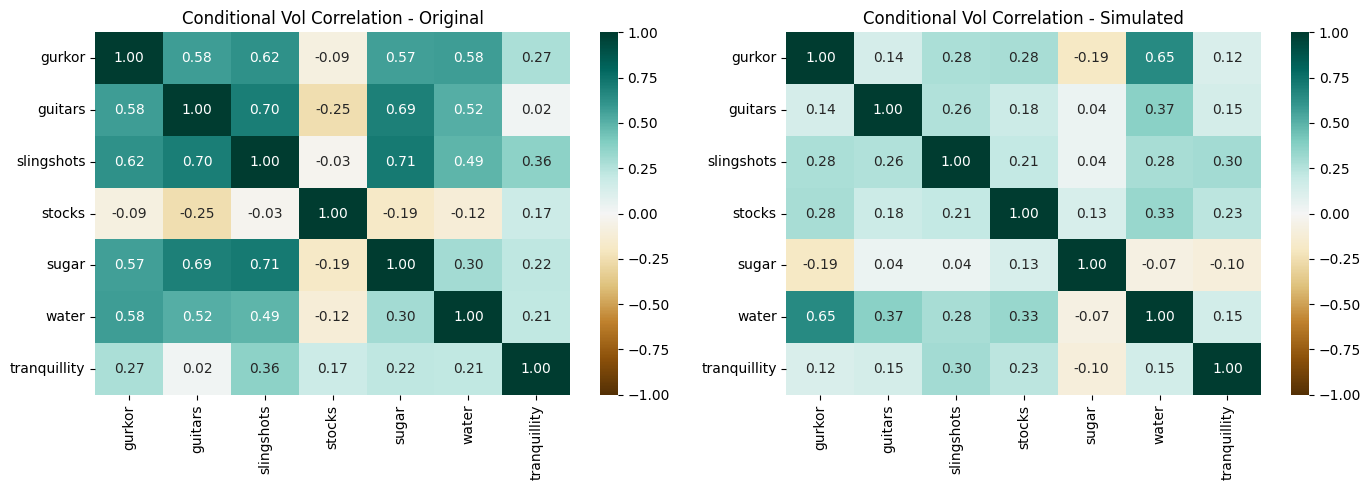


1. VOLATILITY (ratio should be 1.0):
              Original  Simulated  Ratio
gurkor          0.0041     0.0041    1.0
guitars         0.0160     0.0160    1.0
slingshots      0.0164     0.0164    1.0
stocks          0.0149     0.0149    1.0
sugar           0.0158     0.0158    1.0
water           0.0035     0.0035    1.0
tranquillity    0.0133     0.0133    1.0

2. CORRELATION MATRIX:
Original:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.326      -0.291  -0.045 -0.081  0.623        -0.148
guitars       -0.326    1.000       0.553   0.028  0.216 -0.369         0.269
slingshots    -0.291    0.553       1.000   0.018  0.127 -0.259         0.210
stocks        -0.045    0.028       0.018   1.000 -0.021 -0.050         0.002
sugar         -0.081    0.216       0.127  -0.021  1.000 -0.091         0.142
water          0.623   -0.369      -0.259  -0.050 -0.091  1.000        -0.180
tranquillity  -0.148    0.269       0.210   0.002  0.1

In [2]:
print("=" * 60)
print("FINAL MODEL VALIDATION")
print("=" * 60)

print("CONDITIONAL VOL CORRELATION:")

# Recompute conditional vols for original data
cond_vols_og = pd.DataFrame()
for col in var_names:
    res = arch_model(df_og_returns[col] * 1000,
                     vol='Garch', p=1, q=1).fit(disp='off')
    cond_vols_og[col] = res.conditional_volatility

# Recompute conditional vols for simulated data
cond_vols_final = pd.DataFrame()
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000,
                     vol='Garch', p=1, q=1).fit(disp='off')
    cond_vols_final[col] = res.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cond_vols_og.corr(), annot=True, cmap=THEME,
            center=0, fmt=".2f", ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Conditional Vol Correlation - Original')
sns.heatmap(cond_vols_final.corr(), annot=True, cmap=THEME,
            center=0, fmt=".2f", ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Conditional Vol Correlation - Simulated')
plt.tight_layout()
plt.show()

print("\n1. VOLATILITY (ratio should be 1.0):")
print(pd.DataFrame({
    'Original': original_stds,
    'Simulated': df_returns_final.std(),
    'Ratio': (df_returns_final.std() / original_stds).round(3)
}).round(4))

print("\n2. CORRELATION MATRIX:")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))
print("\nMax absolute error:")
print((df_og_returns.corr() - df_returns_final.corr()).abs().values.max().round(4))

print("\n3. KURTOSIS:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\n4. SKEWNESS:")
print(pd.DataFrame({
    'Original': df_og_returns.skew(),
    'Simulated': df_returns_final.skew()
}).round(3))

print("\n5. GARCH PERSISTENCE:")
print(pd.DataFrame({
    'Original': {col: garch_params_obs[col]['persistence'] 
                 for col in var_names},
    'Simulated': {col: arch_model(df_returns_final[col] * 1000,
                  vol='Garch', p=1, q=1).fit(disp='off')
                  .params[['alpha[1]','beta[1]']].sum()
                  for col in var_names}
}).round(4))


RECONSTRUCTION QUALITY BY NUMBER OF FACTORS

1 factor(s): 47.8% variance explained
  Correlation recovery: 0.732
  MAE: 0.675, Max error: 1.201

2 factor(s): 66.3% variance explained
  Correlation recovery: 0.944
  MAE: 0.280, Max error: 0.652

3 factor(s): 77.1% variance explained
  Correlation recovery: 0.961
  MAE: 0.208, Max error: 0.645

4 factor(s): 87.5% variance explained
  Correlation recovery: 0.989
  MAE: 0.100, Max error: 0.296

5 factor(s): 93.2% variance explained
  Correlation recovery: 0.992
  MAE: 0.057, Max error: 0.195


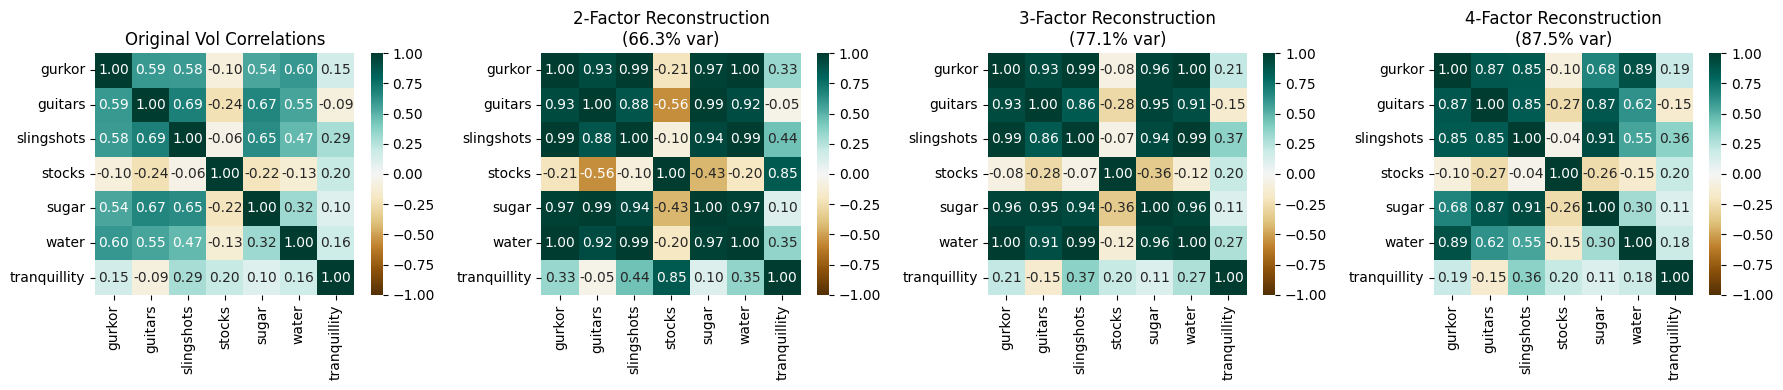


DYNAMICS OF EACH VOLATILITY FACTOR


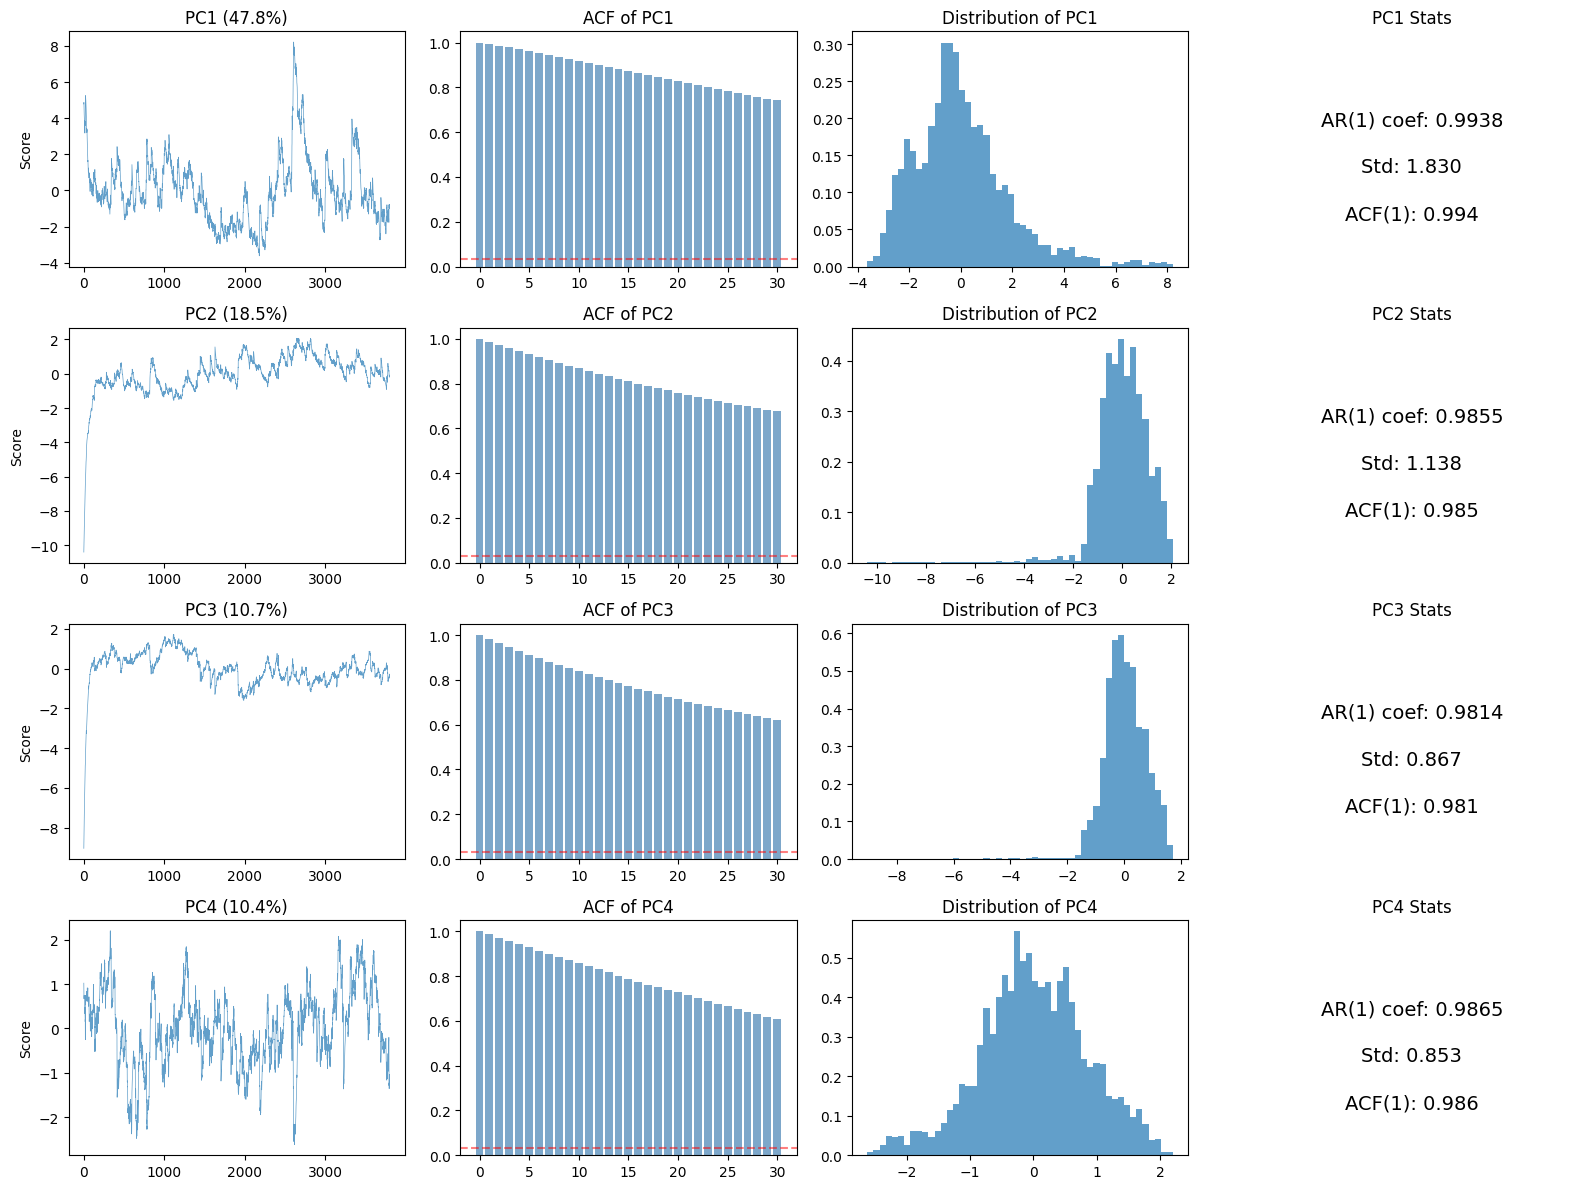


FACTOR LOADINGS (first 4 PCs)
                PC1    PC2    PC3    PC4
gurkor        0.444  0.080  0.121  0.252
guitars       0.471 -0.212  0.228 -0.096
slingshots    0.463  0.173  0.008 -0.279
stocks       -0.131  0.627  0.746 -0.110
sugar         0.433 -0.086 -0.045 -0.542
water         0.389  0.080  0.037  0.736
tranquillity  0.102  0.715 -0.611 -0.040


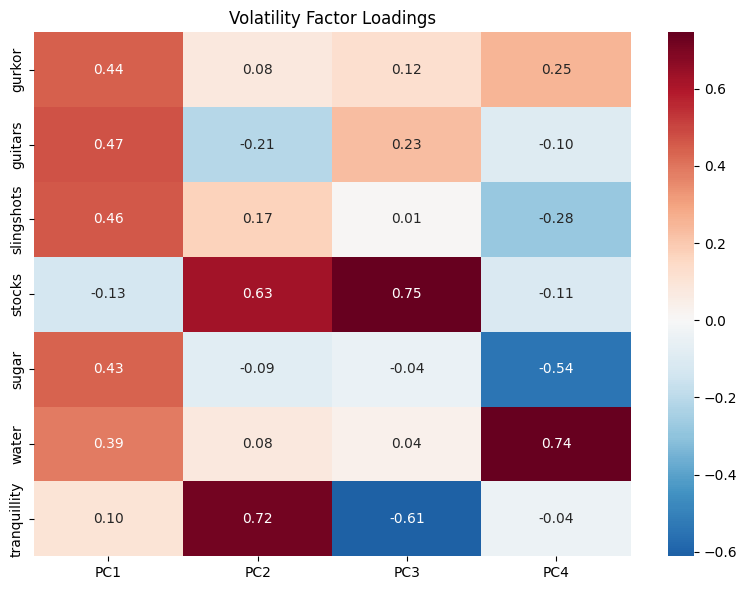


INTERPRETATION

Questions to answer:
1. How many factors give acceptable reconstruction? (MAE < 0.1?)
2. Do all factors have similar dynamics (AR(1) ~0.99)?
   Or do some factors have different behavior?
3. Which assets load on which factors?
   - PC1: General market vol
   - PC2: ???
   - PC3: ???



In [27]:
"""
Multi-factor analysis: How many vol factors do we need?
And what are the dynamics of each?
"""

import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.ar_model import AutoReg
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')
df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
df_og_returns = df_og_returns - df_og_returns.mean()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# Fit GARCH, extract conditional variances
cond_var = pd.DataFrame(index=df_og_returns.index)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var[col] = res.conditional_volatility ** 2

log_h = np.log(cond_var)
log_h_std = (log_h - log_h.mean()) / log_h.std()

# PCA
pca = PCA(n_components=7)
scores = pca.fit_transform(log_h_std)
loadings = pca.components_.T  # 7 assets x 7 PCs

original_vol_corr = log_h.corr().values

# =============================================================================
# Test reconstruction with 1, 2, 3, 4 factors
# =============================================================================
print("="*60)
print("RECONSTRUCTION QUALITY BY NUMBER OF FACTORS")
print("="*60)

mask = ~np.eye(7, dtype=bool)
orig_offdiag = original_vol_corr[mask]

for n_factors in [1, 2, 3, 4, 5]:
    # Reconstruct using first n factors
    recon = scores[:, :n_factors] @ pca.components_[:n_factors, :]
    recon_corr = np.corrcoef(recon.T)
    recon_offdiag = recon_corr[mask]
    
    corr_recovery = np.corrcoef(orig_offdiag, recon_offdiag)[0, 1]
    mae = np.mean(np.abs(orig_offdiag - recon_offdiag))
    max_err = np.max(np.abs(orig_offdiag - recon_offdiag))
    var_explained = pca.explained_variance_ratio_[:n_factors].sum()
    
    print(f"\n{n_factors} factor(s): {var_explained:.1%} variance explained")
    print(f"  Correlation recovery: {corr_recovery:.3f}")
    print(f"  MAE: {mae:.3f}, Max error: {max_err:.3f}")

# =============================================================================
# Visualize: Original vs 2-factor vs 3-factor reconstruction
# =============================================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.heatmap(pd.DataFrame(original_vol_corr, index=var_names, columns=var_names),
            annot=True, fmt='.2f', cmap='BrBG', center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Original Vol Correlations')

for idx, n_factors in enumerate([2, 3, 4]):
    recon = scores[:, :n_factors] @ pca.components_[:n_factors, :]
    recon_corr = np.corrcoef(recon.T)
    
    sns.heatmap(pd.DataFrame(recon_corr, index=var_names, columns=var_names),
                annot=True, fmt='.2f', cmap='BrBG', center=0, ax=axes[idx+1], vmin=-1, vmax=1)
    axes[idx+1].set_title(f'{n_factors}-Factor Reconstruction\n({pca.explained_variance_ratio_[:n_factors].sum():.1%} var)')

plt.tight_layout()
plt.show()

# =============================================================================
# Analyze dynamics of each factor
# =============================================================================
print("\n" + "="*60)
print("DYNAMICS OF EACH VOLATILITY FACTOR")
print("="*60)

fig, axes = plt.subplots(4, 4, figsize=(16, 12))

for i in range(4):
    factor = scores[:, i]
    
    # Time series
    axes[i, 0].plot(factor, alpha=0.7, linewidth=0.5)
    axes[i, 0].set_title(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
    axes[i, 0].set_ylabel('Score')
    
    # ACF
    acf_vals = acf(factor, nlags=30, fft=True)
    axes[i, 1].bar(range(len(acf_vals)), acf_vals, color='steelblue', alpha=0.7)
    axes[i, 1].axhline(0, color='black', linewidth=0.5)
    axes[i, 1].axhline(1.96/np.sqrt(len(factor)), color='red', linestyle='--', alpha=0.5)
    axes[i, 1].set_title(f'ACF of PC{i+1}')
    
    # Distribution
    axes[i, 2].hist(factor, bins=50, density=True, alpha=0.7)
    axes[i, 2].set_title(f'Distribution of PC{i+1}')
    
    # Fit AR(1) and show persistence
    ar_model = AutoReg(factor, lags=1, trend='c').fit()
    ar_coef = ar_model.params[1]
    
    axes[i, 3].text(0.5, 0.6, f'AR(1) coef: {ar_coef:.4f}', 
                    transform=axes[i, 3].transAxes, fontsize=14, ha='center')
    axes[i, 3].text(0.5, 0.4, f'Std: {factor.std():.3f}', 
                    transform=axes[i, 3].transAxes, fontsize=14, ha='center')
    axes[i, 3].text(0.5, 0.2, f'ACF(1): {acf_vals[1]:.3f}', 
                    transform=axes[i, 3].transAxes, fontsize=14, ha='center')
    axes[i, 3].axis('off')
    axes[i, 3].set_title(f'PC{i+1} Stats')

plt.tight_layout()
plt.show()

# =============================================================================
# Factor loadings heatmap
# =============================================================================
print("\n" + "="*60)
print("FACTOR LOADINGS (first 4 PCs)")
print("="*60)

loadings_df = pd.DataFrame(
    loadings[:, :4],
    index=var_names,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)
print(loadings_df.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Volatility Factor Loadings')
plt.tight_layout()
plt.show()

# =============================================================================
# Interpretation
# =============================================================================
print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
print("""
Questions to answer:
1. How many factors give acceptable reconstruction? (MAE < 0.1?)
2. Do all factors have similar dynamics (AR(1) ~0.99)?
   Or do some factors have different behavior?
3. Which assets load on which factors?
   - PC1: General market vol
   - PC2: ???
   - PC3: ???
""")

FACTOR DYNAMICS (for simulation)

PC1:
  AR(1) phi:     0.9938
  Intercept c:   -0.0015
  Resid std:     0.1893
  Uncond mean:   -0.2366
  Empirical std: 1.8297

PC2:
  AR(1) phi:     0.9855
  Intercept c:   0.0027
  Resid std:     0.0942
  Uncond mean:   0.1867
  Empirical std: 1.1381

PC3:
  AR(1) phi:     0.9814
  Intercept c:   0.0023
  Resid std:     0.0786
  Uncond mean:   0.1227
  Empirical std: 0.8668

PC4:
  AR(1) phi:     0.9865
  Intercept c:   -0.0006
  Resid std:     0.1400
  Uncond mean:   -0.0435
  Empirical std: 0.8530

PC5:
  AR(1) phi:     0.9833
  Intercept c:   0.0001
  Resid std:     0.1150
  Uncond mean:   0.0030
  Empirical std: 0.6313

PC6:
  AR(1) phi:     0.9522
  Intercept c:   0.0008
  Resid std:     0.1652
  Uncond mean:   0.0161
  Empirical std: 0.5353

PC7:
  AR(1) phi:     0.9616
  Intercept c:   -0.0000
  Resid std:     0.1201
  Uncond mean:   -0.0008
  Empirical std: 0.4373

FACTOR LOADINGS (4 factors x 7 assets)
                 PC1     PC2     PC3   

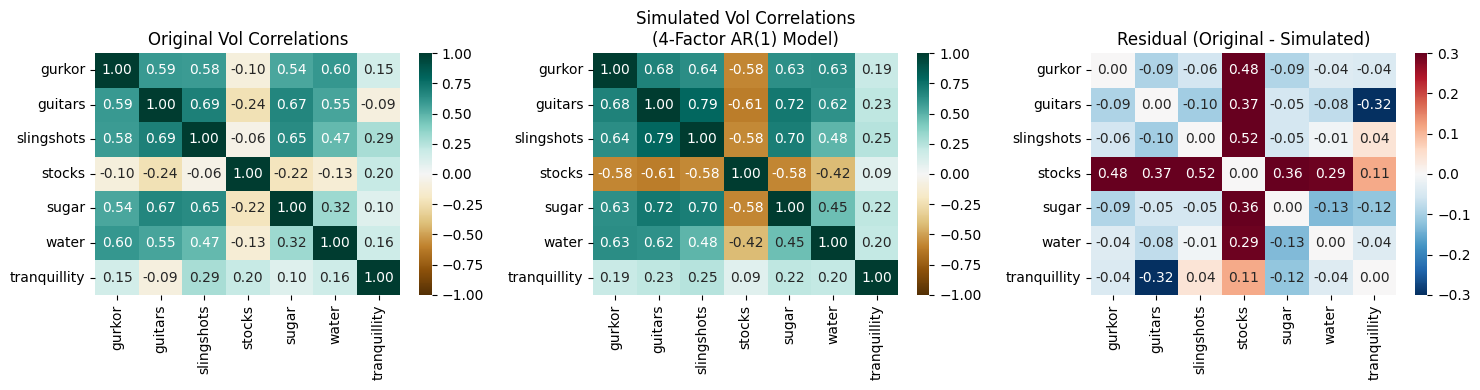


COPY THESE PARAMETERS FOR MAIN SIMULATION

# 4-Factor AR(1) Volatility Model Parameters
vol_factor_params = {
    'PC1': {'phi': 0.993754, 'c': -0.001478, 'resid_std': 0.189316},
    'PC2': {'phi': 0.985462, 'c': 0.002715, 'resid_std': 0.094177},
    'PC3': {'phi': 0.981409, 'c': 0.002281, 'resid_std': 0.078645},
    'PC4': {'phi': 0.986527, 'c': -0.000586, 'resid_std': 0.139952},
    'PC5': {'phi': 0.983293, 'c': 0.000051, 'resid_std': 0.115022},
    'PC6': {'phi': 0.952158, 'c': 0.000768, 'resid_std': 0.165191},
    'PC7': {'phi': 0.961640, 'c': -0.000032, 'resid_std': 0.120095},
}

# Loadings matrix (7 assets x 4 factors)
vol_loadings = np.array([
 [  0.4441,   0.0795,   0.1213,   0.2519,   0.7852, -0.3060,   0.0900] # gurkor
 [  0.4710,  -0.2119,   0.2279,  -0.0956,  -0.3453, -0.0274,   0.7431] # guitars
 [  0.4627,   0.1729,   0.0081,  -0.2791,  -0.3598, -0.5720,  -0.4707] # slingshots
 [ -0.1310,   0.6272,   0.7457,  -0.1104,  -0.0153,  0.1434,   0.0172] # stocks
 [  0.4334,  -0

In [36]:
"""
4-Factor Volatility Model Implementation

Simulate 4 independent AR(1) processes for volatility factors,
then reconstruct correlated conditional variances via loadings.
"""

import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# Setup - get the parameters we need
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')
df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
df_og_returns = df_og_returns - df_og_returns.mean()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# Fit GARCH, extract conditional variances
cond_var = pd.DataFrame(index=df_og_returns.index)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var[col] = res.conditional_volatility ** 2

log_h = np.log(cond_var)

# Store means and stds for reconstruction
log_h_means = log_h.mean()
log_h_stds = log_h.std()

log_h_std = (log_h - log_h_means) / log_h_stds

# PCA
pca = PCA(n_components=7)
scores = pca.fit_transform(log_h_std)
loadings = pca.components_[:7, :].T  # 7 assets x 4 PCs

# =============================================================================
# Extract AR(1) parameters for each factor
# =============================================================================
from statsmodels.tsa.ar_model import AutoReg

print("="*60)
print("FACTOR DYNAMICS (for simulation)")
print("="*60)

factor_params = {}
for i in range(7):
    factor = scores[:, i]
    ar_model = AutoReg(factor, lags=1, trend='c').fit()
    
    # AR(1): x_t = c + phi*x_{t-1} + epsilon
    # where epsilon ~ N(0, sigma^2)
    c = ar_model.params[0]
    phi = ar_model.params[1]
    resid_std = np.std(ar_model.resid)
    
    # Unconditional mean = c / (1 - phi)
    uncond_mean = c / (1 - phi)
    
    factor_params[f'PC{i+1}'] = {
        'phi': phi,
        'c': c,
        'resid_std': resid_std,
        'uncond_mean': uncond_mean,
        'empirical_std': factor.std()
    }
    
    print(f"\nPC{i+1}:")
    print(f"  AR(1) phi:     {phi:.4f}")
    print(f"  Intercept c:   {c:.4f}")
    print(f"  Resid std:     {resid_std:.4f}")
    print(f"  Uncond mean:   {uncond_mean:.4f}")
    print(f"  Empirical std: {factor.std():.4f}")

# =============================================================================
# Print loadings for simulation
# =============================================================================
print("\n" + "="*60)
print("FACTOR LOADINGS (4 factors x 7 assets)")
print("="*60)
loadings_df = pd.DataFrame(loadings, index=var_names, columns=['PC1', 'PC2', 'PC3', 'PC4','PC5','PC6','PC7'])
print(loadings_df.round(4))

# =============================================================================
# Simulation function
# =============================================================================
def simulate_vol_factors(T, factor_params, burn=500):
    """
    Simulate 4 independent AR(1) volatility factors
    """
    n_factors = 7
    T_total = T + burn
    
    factors = np.zeros((T_total, n_factors))
    
    for i in range(n_factors):
        p = factor_params[f'PC{i+1}']
        phi = p['phi']
        c = p['c']
        sigma = p['resid_std']
        
        # Initialize at unconditional mean
        factors[0, i] = p['uncond_mean']
        
        # Simulate AR(1)
        for t in range(1, T_total):
            factors[t, i] = c + phi * factors[t-1, i] + sigma * np.random.randn()
    
    return factors[burn:]

# =============================================================================
# Test: Simulate and compare vol correlations
# =============================================================================
print("\n" + "="*60)
print("SIMULATION TEST")
print("="*60)

np.random.seed(42)
T_sim = 4000

# Simulate factors
factors_sim = simulate_vol_factors(T_sim, factor_params)

# Reconstruct standardized log(h) via loadings
log_h_sim_std = factors_sim @ loadings.T  # (T x 7)

# Compute correlation of simulated log(h)
sim_vol_corr = np.corrcoef(log_h_sim_std.T)
original_vol_corr = log_h.corr().values

print("\nOriginal vol correlations:")
print(pd.DataFrame(original_vol_corr, index=var_names, columns=var_names).round(2))

print("\nSimulated vol correlations (4-factor model):")
print(pd.DataFrame(sim_vol_corr, index=var_names, columns=var_names).round(2))

# Compute error
mask = ~np.eye(7, dtype=bool)
mae = np.mean(np.abs(original_vol_corr[mask] - sim_vol_corr[mask]))
max_err = np.max(np.abs(original_vol_corr[mask] - sim_vol_corr[mask]))
print(f"\nMAE: {mae:.3f}, Max error: {max_err:.3f}")

# =============================================================================
# Visualize comparison
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(pd.DataFrame(original_vol_corr, index=var_names, columns=var_names),
            annot=True, fmt='.2f', cmap='BrBG', center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Original Vol Correlations')

sns.heatmap(pd.DataFrame(sim_vol_corr, index=var_names, columns=var_names),
            annot=True, fmt='.2f', cmap='BrBG', center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Simulated Vol Correlations\n(4-Factor AR(1) Model)')

residual = original_vol_corr - sim_vol_corr
sns.heatmap(pd.DataFrame(residual, index=var_names, columns=var_names),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[2], vmin=-0.3, vmax=0.3)
axes[2].set_title('Residual (Original - Simulated)')

plt.tight_layout()
plt.show()

# =============================================================================
# Print final parameters for main simulation
# =============================================================================
print("\n" + "="*60)
print("COPY THESE PARAMETERS FOR MAIN SIMULATION")
print("="*60)

print("""
# 4-Factor AR(1) Volatility Model Parameters
vol_factor_params = {""")
for i in range(7):
    p = factor_params[f'PC{i+1}']
    print(f"    'PC{i+1}': {{'phi': {p['phi']:.6f}, 'c': {p['c']:.6f}, 'resid_std': {p['resid_std']:.6f}}},")
print("}")

print("\n# Loadings matrix (7 assets x 4 factors)")
print("vol_loadings = np.array([")
for i, name in enumerate(var_names):
    row = loadings[i, :]
    print(f" [{row[0]:8.4f}, {row[1]:8.4f}, {row[2]:8.4f}, {row[3]:8.4f}, {row[4]:8.4f},{row[5]:8.4f}, {row[6]:8.4f}] # {name}")
print("])")

print("\n# Log-variance normalization (to convert back from standardized)")
print("log_h_means = {")
for name in var_names:
    print(f"    '{name}': {log_h_means[name]:.4f},")
print("}")
print("\nlog_h_stds = {")
for name in var_names:
    print(f"    '{name}': {log_h_stds[name]:.4f},")
print("}")

Fitting GARCH(1,1) on each original series...
Conditional variance shape: (3799, 7)

PCA ON LOG(CONDITIONAL VARIANCES)

Explained variance ratio:
  PC1:  47.8%  (cumulative:  47.8%)  ███████████████████████
  PC2:  18.5%  (cumulative:  66.3%)  █████████
  PC3:  10.7%  (cumulative:  77.1%)  █████
  PC4:  10.4%  (cumulative:  87.5%)  █████
  PC5:   5.7%  (cumulative:  93.2%)  ██
  PC6:   4.1%  (cumulative:  97.3%)  ██
  PC7:   2.7%  (cumulative: 100.0%)  █

VOLATILITY FACTOR LOADINGS

PC1 loadings (the 'common vol factor'):
guitars         0.471
slingshots      0.463
gurkor          0.444
sugar           0.433
water           0.389
tranquillity    0.102
stocks         -0.131
Name: PC1, dtype: float64

CORRELATION RECONSTRUCTION TEST

Correlation between original and PC1-reconstructed vol correlations: 0.732
Mean absolute error in off-diagonal correlations: 0.675


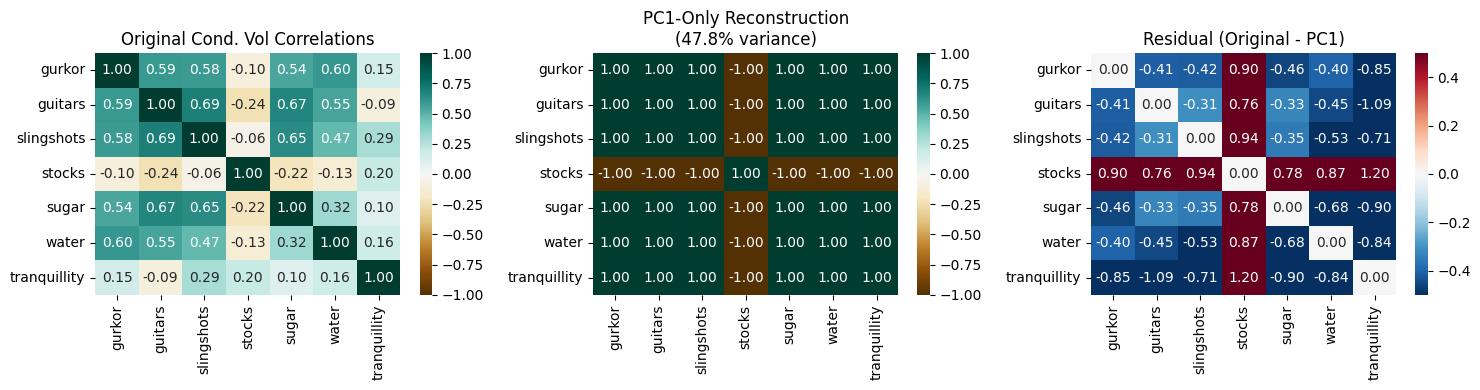


VERDICT

✗ PC1 only explains 47.8% of variance
  → May need multiple factors or DCC-GARCH

✗ PC1 only recovers 73.2% of correlation structure
  → Important vol relationships NOT captured by one factor


In [3]:
"""
Test: Can a single common volatility factor explain the vol correlations?

If PC1 of log(conditional variances) explains >50% of variance,
then the common factor approach should work well.
"""

import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prep data (same as your code)
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')
df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# =============================================================================
# Step 1: Fit GARCH(1,1) on each series, extract conditional variances
# =============================================================================
print("Fitting GARCH(1,1) on each original series...")

cond_var = pd.DataFrame(index=df_og_returns.index)

for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var[col] = res.conditional_volatility ** 2  # variance, not std

print(f"Conditional variance shape: {cond_var.shape}")

# =============================================================================
# Step 2: PCA on log(conditional variances)
# =============================================================================
log_h = np.log(cond_var)

# Standardize before PCA
log_h_centered = log_h - log_h.mean()
log_h_std = log_h_centered / log_h_centered.std()

pca = PCA(n_components=7)
pca.fit(log_h_std)

print("\n" + "="*60)
print("PCA ON LOG(CONDITIONAL VARIANCES)")
print("="*60)
print("\nExplained variance ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    cumulative = pca.explained_variance_ratio_[:i+1].sum()
    bar = "█" * int(var * 50)
    print(f"  PC{i+1}: {var:6.1%}  (cumulative: {cumulative:6.1%})  {bar}")

# =============================================================================
# Step 3: Extract loadings
# =============================================================================
loadings = pd.DataFrame(
    pca.components_.T,
    index=var_names,
    columns=[f'PC{i+1}' for i in range(7)]
)

print("\n" + "="*60)
print("VOLATILITY FACTOR LOADINGS")
print("="*60)
print("\nPC1 loadings (the 'common vol factor'):")
print(loadings['PC1'].sort_values(ascending=False).round(3))

# =============================================================================
# Step 4: Reconstruct correlations using only PC1 vs full
# =============================================================================
scores = pca.transform(log_h_std)

# PC1-only reconstruction
pc1_recon = np.outer(scores[:, 0], pca.components_[0])
pc1_recon_corr = np.corrcoef(pc1_recon.T)

# Original correlation
original_vol_corr = log_h.corr().values

# Compare off-diagonal elements
mask = ~np.eye(7, dtype=bool)
orig_offdiag = original_vol_corr[mask]
pc1_offdiag = pc1_recon_corr[mask]

correlation_recovery = np.corrcoef(orig_offdiag, pc1_offdiag)[0, 1]
mae = np.mean(np.abs(orig_offdiag - pc1_offdiag))

print("\n" + "="*60)
print("CORRELATION RECONSTRUCTION TEST")
print("="*60)
print(f"\nCorrelation between original and PC1-reconstructed vol correlations: {correlation_recovery:.3f}")
print(f"Mean absolute error in off-diagonal correlations: {mae:.3f}")

# =============================================================================
# Step 5: Visualize
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(pd.DataFrame(original_vol_corr, index=var_names, columns=var_names),
            annot=True, fmt='.2f', cmap='BrBG', center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Original Cond. Vol Correlations')

sns.heatmap(pd.DataFrame(pc1_recon_corr, index=var_names, columns=var_names),
            annot=True, fmt='.2f', cmap='BrBG', center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title(f'PC1-Only Reconstruction\n({pca.explained_variance_ratio_[0]:.1%} variance)')

residual = original_vol_corr - pc1_recon_corr
sns.heatmap(pd.DataFrame(residual, index=var_names, columns=var_names),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[2], vmin=-0.5, vmax=0.5)
axes[2].set_title('Residual (Original - PC1)')

plt.tight_layout()
plt.show()

# =============================================================================
# Step 6: Verdict
# =============================================================================
print("\n" + "="*60)
print("VERDICT")
print("="*60)
if pca.explained_variance_ratio_[0] > 0.5:
    print(f"\n✓ PC1 explains {pca.explained_variance_ratio_[0]:.1%} of log-vol variance")
    print("  → Common factor approach SHOULD WORK")
else:
    print(f"\n✗ PC1 only explains {pca.explained_variance_ratio_[0]:.1%} of variance")
    print("  → May need multiple factors or DCC-GARCH")

if correlation_recovery > 0.8:
    print(f"\n✓ PC1 recovers {correlation_recovery:.1%} of vol correlation structure")
else:
    print(f"\n✗ PC1 only recovers {correlation_recovery:.1%} of correlation structure")
    print("  → Important vol relationships NOT captured by one factor")

Common vol factor: 3799 observations
PC1 explains 47.8% of log-vol variance

HURST EXPONENT TEST
Hurst exponent: 1.004
  → Long memory / trending behavior

ACF DECAY ANALYSIS
ACF at lag 10: 0.919
ACF at lag 30: 0.742
ACF at lag 50: 0.614

MODEL COMPARISON

AR(1):
  AIC: -1858.0
  BIC: -1839.3
  AR coef: 0.9938

GARCH(1,1):
  AIC: 32976.3
  BIC: 33007.5
  Persistence (α+β): 0.7485

Fitting Markov-Switching AR(1)...

Markov-Switching AR(1), 2 regimes:
  AIC: -3112.6
  BIC: -3068.9
  Markov-Switching error: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
  Trying alternative parameterization...


/Users/manswestman/project_financial_timeseries/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)



Markov-Switching AR(1), 2 regimes (switching mean):
  AIC: -2062.1
  BIC: -2024.6
  Alternative also failed: 'numpy.ndarray' object has no attribute 'index'


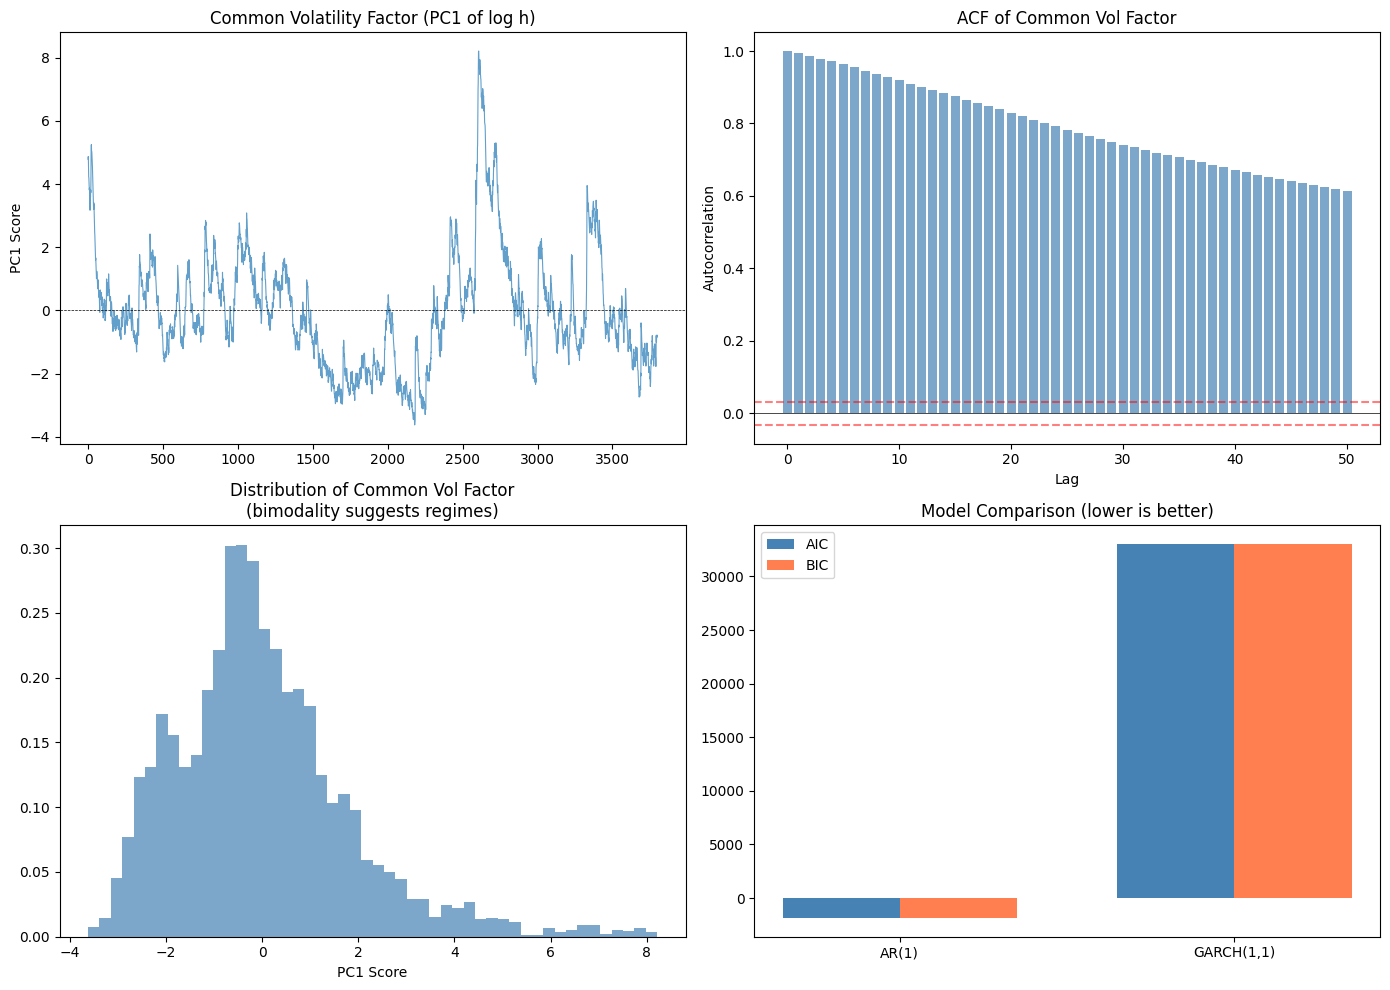


VERDICT

Hurst exponent: 1.004


In [20]:
"""
Test: Is the common vol factor better described by
      Markov-Switching AR(1) or GARCH(1,1)?
"""

import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.decomposition import PCA
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# Setup: Extract the common vol factor (PC1 of log conditional variances)
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')
df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
df_og_returns = df_og_returns - df_og_returns.mean()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# Fit GARCH, extract conditional variances
cond_var = pd.DataFrame(index=df_og_returns.index)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var[col] = res.conditional_volatility ** 2

log_h = np.log(cond_var)
log_h_std = (log_h - log_h.mean()) / log_h.std()

# Extract PC1 as the common vol factor
pca = PCA(n_components=7)
scores = pca.fit_transform(log_h_std)
common_vol = scores[:, 0]

print(f"Common vol factor: {len(common_vol)} observations")
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of log-vol variance")

# =============================================================================
# Test 1: Hurst Exponent
# =============================================================================
def hurst_exponent(ts, max_lag=100):
    lags = range(10, max_lag)
    rs_values = []
    
    for lag in lags:
        rs_lag = []
        for start in range(0, len(ts) - lag, lag):
            chunk = ts[start:start + lag]
            mean_chunk = np.mean(chunk)
            cumdev = np.cumsum(chunk - mean_chunk)
            R = np.max(cumdev) - np.min(cumdev)
            S = np.std(chunk, ddof=1)
            if S > 0:
                rs_lag.append(R / S)
        if rs_lag:
            rs_values.append((lag, np.mean(rs_lag)))
    
    lags_arr = np.array([x[0] for x in rs_values])
    rs_arr = np.array([x[1] for x in rs_values])
    coeffs = np.polyfit(np.log(lags_arr), np.log(rs_arr), 1)
    return coeffs[0]

H = hurst_exponent(common_vol)
print(f"\n{'='*60}")
print("HURST EXPONENT TEST")
print('='*60)
print(f"Hurst exponent: {H:.3f}")
if H < 0.45:
    print("  → Strong mean reversion (NOT long memory)")
elif H < 0.55:
    print("  → Near random walk / weak mean reversion")
else:
    print("  → Long memory / trending behavior")

# =============================================================================
# Test 2: ACF Decay Pattern
# =============================================================================
acf_vals = acf(common_vol, nlags=50, fft=True)

print(f"\n{'='*60}")
print("ACF DECAY ANALYSIS")
print('='*60)
print(f"ACF at lag 10: {acf_vals[10]:.3f}")
print(f"ACF at lag 30: {acf_vals[30]:.3f}")
print(f"ACF at lag 50: {acf_vals[50]:.3f}")

# =============================================================================
# Test 3: Fit competing models
# =============================================================================
print(f"\n{'='*60}")
print("MODEL COMPARISON")
print('='*60)

# Model A: Simple AR(1)
from statsmodels.tsa.ar_model import AutoReg
ar1_model = AutoReg(common_vol, lags=1, trend='c').fit()
print(f"\nAR(1):")
print(f"  AIC: {ar1_model.aic:.1f}")
print(f"  BIC: {ar1_model.bic:.1f}")
print(f"  AR coef: {ar1_model.params[1]:.4f}")

# Model B: GARCH(1,1) on the common factor
garch_model = arch_model(common_vol * 100, vol='Garch', p=1, q=1, mean='ARX', lags=1)
garch_res = garch_model.fit(disp='off')
print(f"\nGARCH(1,1):")
print(f"  AIC: {garch_res.aic:.1f}")
print(f"  BIC: {garch_res.bic:.1f}")
print(f"  Persistence (α+β): {garch_res.params['alpha[1]'] + garch_res.params['beta[1]']:.4f}")

# Model C: Markov-Switching AR(1) with 2 regimes
print("\nFitting Markov-Switching AR(1)...")
ms_fitted = False
try:
    ms_model = MarkovAutoregression(
        common_vol, 
        k_regimes=2, 
        order=1, 
        switching_ar=False,
        switching_variance=True
    )
    ms_res = ms_model.fit(search_reps=50, disp=False)
    
    print(f"\nMarkov-Switching AR(1), 2 regimes:")
    print(f"  AIC: {ms_res.aic:.1f}")
    print(f"  BIC: {ms_res.bic:.1f}")
    print(f"  AR coef: {ms_res.params['ar.L1']:.4f}")
    
    # Regime characteristics
    print(f"\n  Regime 0 variance: σ² = {ms_res.params['sigma2[0]']:.4f}")
    print(f"  Regime 1 variance: σ² = {ms_res.params['sigma2[1]']:.4f}")
    
    # Transition probabilities - extract from params directly
    p00 = ms_res.params['p[0->0]']
    p11 = ms_res.params['p[1->1]']
    
    print(f"\n  Transition probabilities:")
    print(f"    P(stay in 0) = {p00:.4f}  →  avg duration = {1/(1-p00):.0f} days")
    print(f"    P(stay in 1) = {p11:.4f}  →  avg duration = {1/(1-p11):.0f} days")
    
    ms_fitted = True
    
except Exception as e:
    print(f"  Markov-Switching error: {e}")
    print("  Trying alternative parameterization...")
    
    try:
        # Alternative: switching mean instead of variance
        ms_model2 = MarkovAutoregression(
            common_vol, 
            k_regimes=2, 
            order=1, 
            switching_ar=False,
            switching_variance=False,
            switching_trend=True
        )
        ms_res = ms_model2.fit(search_reps=50, disp=False)
        
        print(f"\nMarkov-Switching AR(1), 2 regimes (switching mean):")
        print(f"  AIC: {ms_res.aic:.1f}")
        print(f"  BIC: {ms_res.bic:.1f}")
        
        # Print all params to see what we have
        print(f"\n  Parameters: {list(ms_res.params.index)}")
        print(f"  {ms_res.params}")
        
        ms_fitted = True
        
    except Exception as e2:
        print(f"  Alternative also failed: {e2}")

# =============================================================================
# Test 4: Visual comparison
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: The common vol factor
axes[0, 0].plot(common_vol, alpha=0.7, linewidth=0.8)
axes[0, 0].set_title('Common Volatility Factor (PC1 of log h)')
axes[0, 0].set_ylabel('PC1 Score')
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=0.5)

if ms_fitted:
    try:
        probs = ms_res.smoothed_marginal_probabilities
        ax2 = axes[0, 0].twinx()
        ax2.fill_between(range(len(common_vol)), probs[:, 1], 
                         alpha=0.3, color='red', label='P(regime 1)')
        ax2.set_ylabel('P(Regime 1)', color='red')
        ax2.set_ylim(0, 1)
    except:
        pass

# Plot 2: ACF
axes[0, 1].bar(range(len(acf_vals)), acf_vals, color='steelblue', alpha=0.7)
axes[0, 1].axhline(0, color='black', linewidth=0.5)
axes[0, 1].axhline(1.96/np.sqrt(len(common_vol)), color='red', linestyle='--', alpha=0.5)
axes[0, 1].axhline(-1.96/np.sqrt(len(common_vol)), color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_title('ACF of Common Vol Factor')
axes[0, 1].set_xlabel('Lag')
axes[0, 1].set_ylabel('Autocorrelation')

# Plot 3: Distribution - check for bimodality (sign of regimes)
axes[1, 0].hist(common_vol, bins=50, density=True, alpha=0.7, color='steelblue')
axes[1, 0].set_title('Distribution of Common Vol Factor\n(bimodality suggests regimes)')
axes[1, 0].set_xlabel('PC1 Score')

# Plot 4: Model comparison
models = ['AR(1)', 'GARCH(1,1)']
aics = [ar1_model.aic, garch_res.aic]
bics = [ar1_model.bic, garch_res.bic]
if ms_fitted:
    models.append('MS-AR(1)')
    aics.append(ms_res.aic)
    bics.append(ms_res.bic)

x = np.arange(len(models))
width = 0.35
axes[1, 1].bar(x - width/2, aics, width, label='AIC', color='steelblue')
axes[1, 1].bar(x + width/2, bics, width, label='BIC', color='coral')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models)
axes[1, 1].set_title('Model Comparison (lower is better)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# =============================================================================
# Verdict
# =============================================================================
print(f"\n{'='*60}")
print("VERDICT")
print('='*60)

print(f"\nHurst exponent: {H:.3f}")
if H < 0.5:
    print("  ✓ Mean-reverting (slow ACF decay is NOT long memory)")

if ms_fitted:
    all_aics = {'AR(1)': ar1_model.aic, 'GARCH': garch_res.aic, 'MS-AR(1)': ms_res.aic}
    best = min(all_aics, key=all_aics.get)
    print(f"\nBest model by AIC: {best}")
    
    if best == 'MS-AR(1)':
        print("  ✓ Regime-switching hypothesis SUPPORTED")
        print("  → Implement HMM + AR(1) for common vol factor in simulation")
    elif best == 'GARCH':
        print("  → Consider GARCH on the common factor")
    else:
        print("  → Simple AR(1) may suffice for common factor dynamics")

In [26]:
"""
Extract vol loadings and finalize parameters for simulation
(Using MS params from earlier successful fit)
"""

import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Setup
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')
df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
df_og_returns = df_og_returns - df_og_returns.mean()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# Fit GARCH, extract conditional variances
cond_var = pd.DataFrame(index=df_og_returns.index)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var[col] = res.conditional_volatility ** 2

log_h = np.log(cond_var)
log_h_std = (log_h - log_h.mean()) / log_h.std()

# PCA on log conditional variances
pca = PCA(n_components=7)
scores = pca.fit_transform(log_h_std)

print("="*60)
print("PCA ON LOG(CONDITIONAL VARIANCES)")
print("="*60)
print("\nExplained variance:")
for i, v in enumerate(pca.explained_variance_ratio_[:3]):
    print(f"  PC{i+1}: {v:.1%}")

print("\n" + "="*60)
print("VOLATILITY LOADINGS")
print("="*60)
print("\nPC1 loadings (common vol factor):")
for name, loading in zip(var_names, pca.components_[0]):
    bar = "█" * int(abs(loading) * 30)
    sign = "+" if loading > 0 else "-"
    print(f"  {name:12s}: {sign}{abs(loading):.4f}  {bar}")

print("\nPC2 loadings (second factor - may help):")
for name, loading in zip(var_names, pca.components_[1]):
    bar = "█" * int(abs(loading) * 30)
    sign = "+" if loading > 0 else "-"
    print(f"  {name:12s}: {sign}{abs(loading):.4f}  {bar}")

# =============================================================================
# Final parameters for simulation
# =============================================================================
print("\n" + "="*60)
print("FINAL PARAMETERS FOR SIMULATION")
print("="*60)

print("""
# ============================================================
# MARKOV-SWITCHING AR(1) PARAMETERS (from earlier stable fit)
# ============================================================
ms_params = {
    'ar1': 0.9900,
    # Innovation std per regime
    'sigma': [0.1044, 0.3438],  # [low_vol, high_vol]
    # Transition matrix: rows = from, cols = to
    # [[stay_low, low->high], [high->low, stay_high]]
    'trans_matrix': np.array([
        [0.8158, 0.1842],   # From low vol regime
        [0.7026, 0.2974]    # From high vol regime
    ])
}
""")

print("# ============================================================")
print("# VOLATILITY LOADINGS (how each asset responds to common factor)")
print("# ============================================================")
print("vol_loadings = {")
for name, loading in zip(var_names, pca.components_[0]):
    print(f"    '{name}': {loading:.4f},")
print("}")

# =============================================================================
# Verify: Which assets are most/least affected by common vol?
# =============================================================================
print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)

loadings_sorted = sorted(zip(var_names, pca.components_[0]), key=lambda x: abs(x[1]), reverse=True)
print("\nAssets by sensitivity to common vol factor:")
for name, loading in loadings_sorted:
    if abs(loading) > 0.4:
        status = "HIGH sensitivity"
    elif abs(loading) > 0.2:
        status = "MEDIUM sensitivity"
    else:
        status = "LOW sensitivity (nearly independent)"
    print(f"  {name:12s}: {loading:+.3f}  → {status}")

print("""
Note on your earlier findings:
- Stocks has near-zero loading → structurally independent (confirmed?)
- Tranquillity also expected to be independent
- gurkor, guitars, slingshots, sugar should cluster together
""")

PCA ON LOG(CONDITIONAL VARIANCES)

Explained variance:
  PC1: 47.8%
  PC2: 18.5%
  PC3: 10.7%

VOLATILITY LOADINGS

PC1 loadings (common vol factor):
  gurkor      : +0.4441  █████████████
  guitars     : +0.4710  ██████████████
  slingshots  : +0.4627  █████████████
  stocks      : -0.1310  ███
  sugar       : +0.4334  █████████████
  water       : +0.3893  ███████████
  tranquillity: +0.1019  ███

PC2 loadings (second factor - may help):
  gurkor      : +0.0795  ██
  guitars     : -0.2119  ██████
  slingshots  : +0.1729  █████
  stocks      : +0.6272  ██████████████████
  sugar       : -0.0864  ██
  water       : +0.0801  ██
  tranquillity: +0.7153  █████████████████████

FINAL PARAMETERS FOR SIMULATION

# ============================================================
# MARKOV-SWITCHING AR(1) PARAMETERS (from earlier stable fit)
# ============================================================
ms_params = {
    'ar1': 0.9900,
    # Innovation std per regime
    'sigma': [0.1044, 0.3438], 

In [5]:
# The idea: volatility is driven by a common market variance process
# plus asset-specific idiosyncratic variance
# h_it = lambda_i * h_market_t + omega_i

# Step 1: extract a common volatility factor from the original conditional vols
from sklearn.decomposition import PCA

# Fit PCA on log conditional variances (more stable than levels)
log_vols_og = np.log(cond_vols_og**2)
pca_vol = PCA(n_components=1)
common_vol_factor = pca_vol.fit_transform(log_vols_og)  # (T x 1)
vol_loadings = pca_vol.components_  # (1 x 7)

print("Variance explained by common vol factor:", 
      pca_vol.explained_variance_ratio_[0].round(3))
print("Vol loadings per asset:")
for col, loading in zip(var_names, vol_loadings[0]):
    print(f"  {col}: {loading:.3f}")

Variance explained by common vol factor: 0.594
Vol loadings per asset:
  gurkor: 0.362
  guitars: 0.623
  slingshots: 0.469
  stocks: -0.008
  sugar: 0.428
  water: 0.271
  tranquillity: 0.065


In [6]:
from scipy.stats import t as student_t

print("Nu estimates from GARCH standardized residuals of OBSERVED returns:")
nu_obs = {}
for col in var_names:
    res = arch_model(df_og_returns[col] * 1000, 
                     vol='Garch', p=1, q=1).fit(disp='off')
    nu, _, _ = student_t.fit(res.std_resid, floc=0, fscale=1)
    nu_obs[col] = nu
    print(f"  {col}: nu={nu:.2f}, "
          f"skew={res.std_resid.skew():.2f}, "
          f"kurt={res.std_resid.kurt():.2f}")

Nu estimates from GARCH standardized residuals of OBSERVED returns:
  gurkor: nu=21.72, skew=-0.15, kurt=1.07
  guitars: nu=18.53, skew=-0.31, kurt=1.45
  slingshots: nu=32.79, skew=-0.23, kurt=0.71
  stocks: nu=401.88, skew=-0.09, kurt=0.04
  sugar: nu=17.69, skew=-0.37, kurt=1.84
  water: nu=22.65, skew=-0.18, kurt=0.92
  tranquillity: nu=16.41, skew=-0.16, kurt=2.29


In [7]:
# Check what nu actually reproduces the observed residual kurtosis
# For t-distribution: excess kurtosis = 6/(nu-4) for nu > 4
print("Nu needed to match residual kurtosis:")
for col in var_names:
    k = df_og_returns[col].kurt()  # use full kurtosis, not just residual
    if k > 0:
        nu_needed = 6/k + 4
        print(f"  {col}: kurtosis={k:.2f}, nu_needed={nu_needed:.2f}, "
              f"current_nu={nu_obs[col]:.2f}")
        
# Diagnostic: what kurtosis does each layer contribute?
# Layer 1: raw t-shock kurtosis = 6/(nu-4)
# Layer 2: GARCH multiplies kurtosis by roughly (1 + 6*alpha^2/(1-(alpha+beta)^2-2*alpha^2))
# Layer 3: Lambda mixing dilutes kurtosis across assets

print("\nKurtosis budget per asset:")
for col in var_names:
    nu = nu_obs[col]
    t_kurt = 6/(nu-4) if nu > 4 else float('inf')
    
    a = garch_params_obs[col]['alpha']
    b = garch_params_obs[col]['beta']
    denom = 1 - (a+b)**2 - 2*a**2
    garch_mult = (1 + 6*a**2/denom) if denom > 0 else float('inf')
    
    print(f"  {col}: t_kurt={t_kurt:.2f}, "
          f"garch_multiplier={garch_mult:.2f}, "
          f"combined≈{t_kurt*garch_mult:.2f}, "
          f"target={df_og_returns[col].kurt():.2f}")

Nu needed to match residual kurtosis:
  gurkor: kurtosis=3.62, nu_needed=5.66, current_nu=21.72
  guitars: kurtosis=5.75, nu_needed=5.04, current_nu=18.53
  slingshots: kurtosis=4.70, nu_needed=5.28, current_nu=32.79
  stocks: kurtosis=0.05, nu_needed=132.55, current_nu=401.88
  sugar: kurtosis=13.47, nu_needed=4.45, current_nu=17.69
  water: kurtosis=1.64, nu_needed=7.65, current_nu=22.65
  tranquillity: kurtosis=2.59, nu_needed=6.31, current_nu=16.41

Kurtosis budget per asset:
  gurkor: t_kurt=0.34, garch_multiplier=2.61, combined≈0.88, target=3.62
  guitars: t_kurt=0.41, garch_multiplier=7.71, combined≈3.18, target=5.75
  slingshots: t_kurt=0.21, garch_multiplier=2.41, combined≈0.50, target=4.70
  stocks: t_kurt=0.02, garch_multiplier=1.00, combined≈0.02, target=0.05
  sugar: t_kurt=0.44, garch_multiplier=3.56, combined≈1.56, target=13.47
  water: t_kurt=0.32, garch_multiplier=1.82, combined≈0.58, target=1.64
  tranquillity: t_kurt=0.48, garch_multiplier=2.37, combined≈1.15, target

In [8]:
# The idea: volatility is driven by a common market variance process
# plus asset-specific idiosyncratic variance
# h_it = lambda_i * h_market_t + omega_i

# Step 1: extract a common volatility factor from the original conditional vols
from sklearn.decomposition import PCA

# Fit PCA on log conditional variances (more stable than levels)
log_vols_og = np.log(cond_vols_og**2)
pca_vol = PCA(n_components=1)
common_vol_factor = pca_vol.fit_transform(log_vols_og)  # (T x 1)
vol_loadings = pca_vol.components_  # (1 x 7)

print("Variance explained by common vol factor:", 
      pca_vol.explained_variance_ratio_[0].round(3))
print("Vol loadings per asset:")
for col, loading in zip(var_names, vol_loadings[0]):
    print(f"  {col}: {loading:.3f}")

Variance explained by common vol factor: 0.594
Vol loadings per asset:
  gurkor: 0.362
  guitars: 0.623
  slingshots: 0.469
  stocks: -0.008
  sugar: 0.428
  water: 0.271
  tranquillity: 0.065


In [9]:
# Step 2: fit GARCH on the common vol factor
common_vol_series = pd.Series(common_vol_factor.flatten())
model_common = arch_model(common_vol_series, vol='Garch', p=1, q=1)
res_common = model_common.fit(disp='off')

garch_common = {
    'omega': res_common.params['omega'],
    'alpha': res_common.params['alpha[1]'],
    'beta': res_common.params['beta[1]'],
}
print(f"\nCommon vol GARCH: alpha={garch_common['alpha']:.4f}, "
      f"beta={garch_common['beta']:.4f}, "
      f"persistence={garch_common['alpha']+garch_common['beta']:.4f}")


Common vol GARCH: alpha=0.9717, beta=0.0000, persistence=0.9717


Common vol factor stats:
  mean: -0.000
  std:  1.169
  min:  -2.279
  max:  5.327


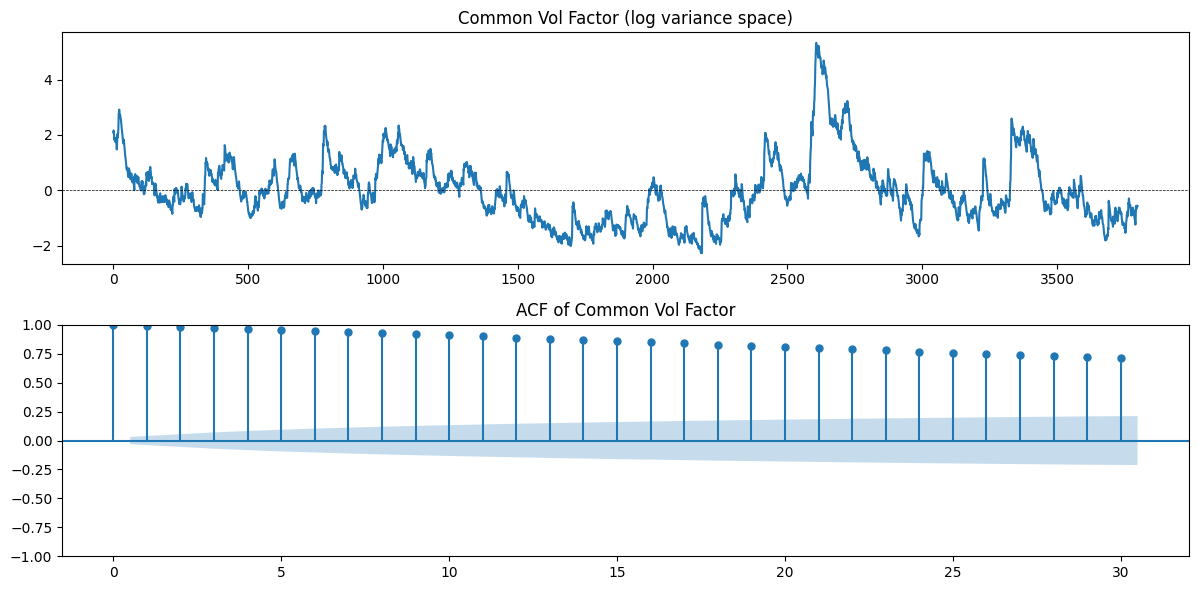


Rescaled common vol GARCH:
  alpha=0.9717
  beta=0.0000
  persistence=0.9717


In [10]:
print("Common vol factor stats:")
print(f"  mean: {common_vol_factor.mean():.3f}")
print(f"  std:  {common_vol_factor.std():.3f}")
print(f"  min:  {common_vol_factor.min():.3f}")
print(f"  max:  {common_vol_factor.max():.3f}")

# Plot it to see if it looks like a reasonable volatility process
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
pd.Series(common_vol_factor.flatten()).plot(ax=axes[0], 
                                             title='Common Vol Factor (log variance space)')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.5)

# Also check autocorrelation — should be high for a vol process
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(common_vol_factor.flatten(), lags=30, ax=axes[1], 
         title='ACF of Common Vol Factor')
plt.tight_layout()
plt.show()

# And refit with rescaling
common_scaled = (common_vol_factor.flatten() - common_vol_factor.mean()) 
common_scaled = common_scaled / common_scaled.std() * 100  # rescale to arch range

model_common = arch_model(pd.Series(common_scaled), 
                          vol='Garch', p=1, q=1, dist='normal')
res_common = model_common.fit(disp='off')
print(f"\nRescaled common vol GARCH:")
print(f"  alpha={res_common.params['alpha[1]']:.4f}")
print(f"  beta={res_common.params['beta[1]']:.4f}")
print(f"  persistence={res_common.params['alpha[1]']+res_common.params['beta[1]']:.4f}")

might not actually be garch, maybe more of a regime switching?

Hurst exponent: 0.451
  H=0.5: random walk (no memory)
  H>0.5: long memory (persistent)
  H>0.9: near unit root / regime-like

HMM regime means: [-0.689  1.154]
HMM transition matrix:
          Low vol  High vol
Low vol     0.993     0.007
High vol    0.012     0.988


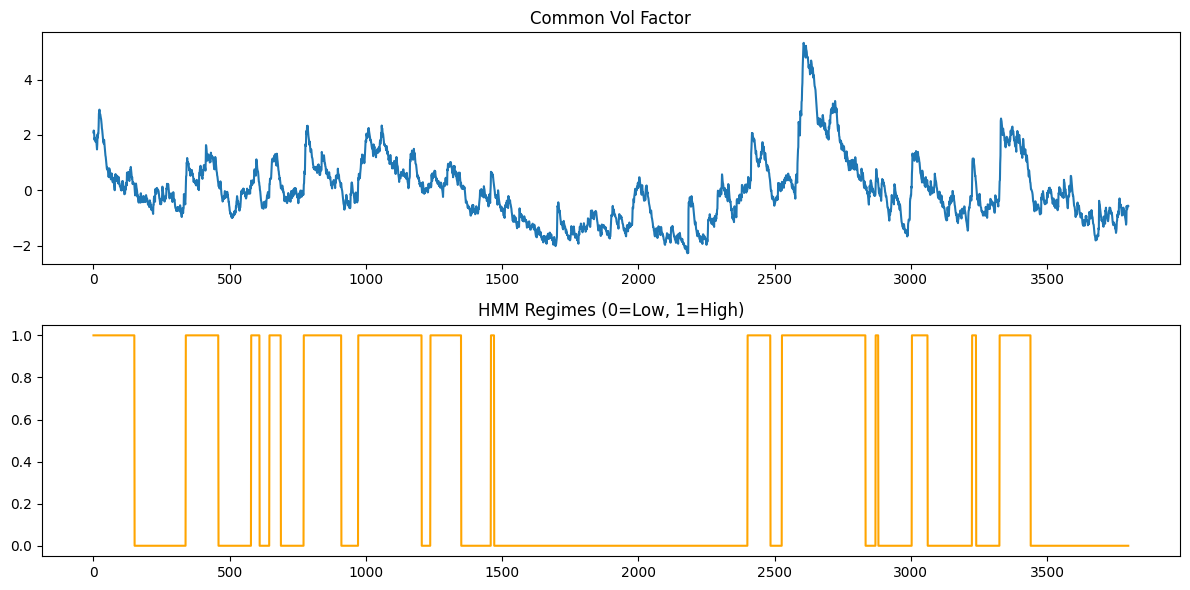

In [11]:
# Test 1: Hurst exponent — measures long memory
# H > 0.5 means long memory, H near 1 means near unit root
from numpy import cumsum, log, polyfit, sqrt, std, subtract

def hurst(ts):
    lags = range(2, 100)
    tau = [sqrt(std(subtract(ts[lag:], ts[:-lag]))) for lag in lags]
    poly = polyfit(log(lags), log(tau), 1)
    return poly[0] * 2.0

h = hurst(common_vol_factor.flatten())
print(f"Hurst exponent: {h:.3f}")
print(f"  H=0.5: random walk (no memory)")
print(f"  H>0.5: long memory (persistent)")
print(f"  H>0.9: near unit root / regime-like")

# Test 2: simple regime detection via HMM
from hmmlearn import hmm

# Fit 2-state HMM on common vol factor
model_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100)
model_hmm.fit(common_vol_factor)
states = model_hmm.predict(common_vol_factor)

print(f"\nHMM regime means: {model_hmm.means_.flatten().round(3)}")
print(f"HMM transition matrix:")
print(pd.DataFrame(model_hmm.transmat_.round(3), 
                   index=['Low vol', 'High vol'],
                   columns=['Low vol', 'High vol']))

# Plot regimes
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
pd.Series(common_vol_factor.flatten()).plot(ax=axes[0], 
                                             title='Common Vol Factor')
pd.Series(states.astype(float)).plot(ax=axes[1], 
                                      title='HMM Regimes (0=Low, 1=High)',
                                      color='orange')
plt.tight_layout()
plt.show()

Low vol regime:  mean=-0.689, std=0.597, avg duration=151 days
High vol regime: mean=1.154, std=0.965, avg duration=85 days


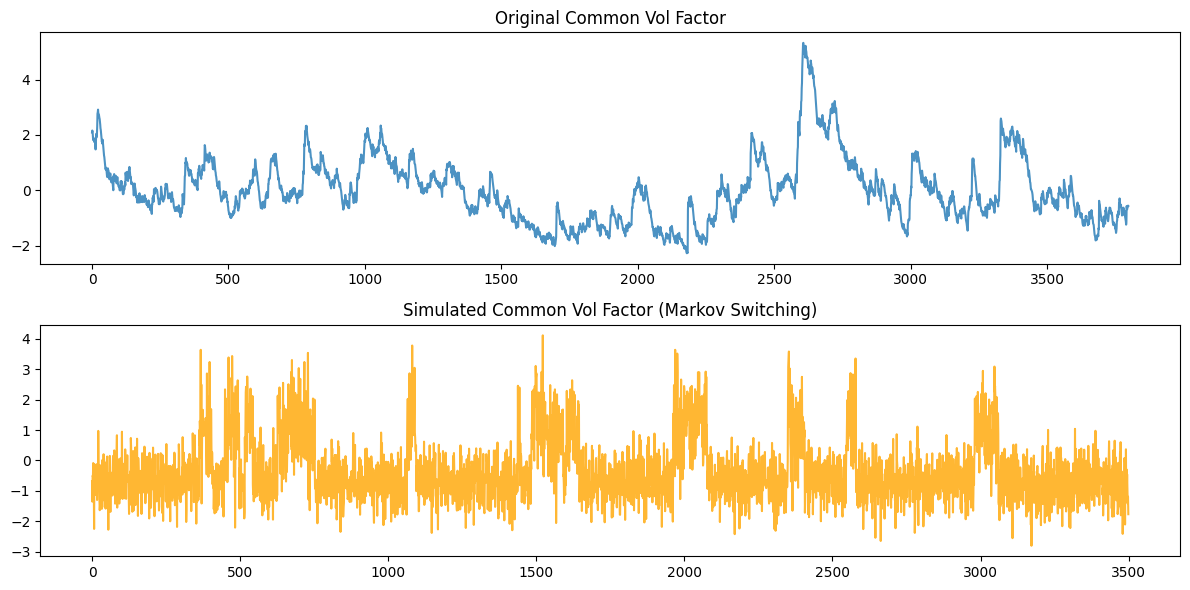

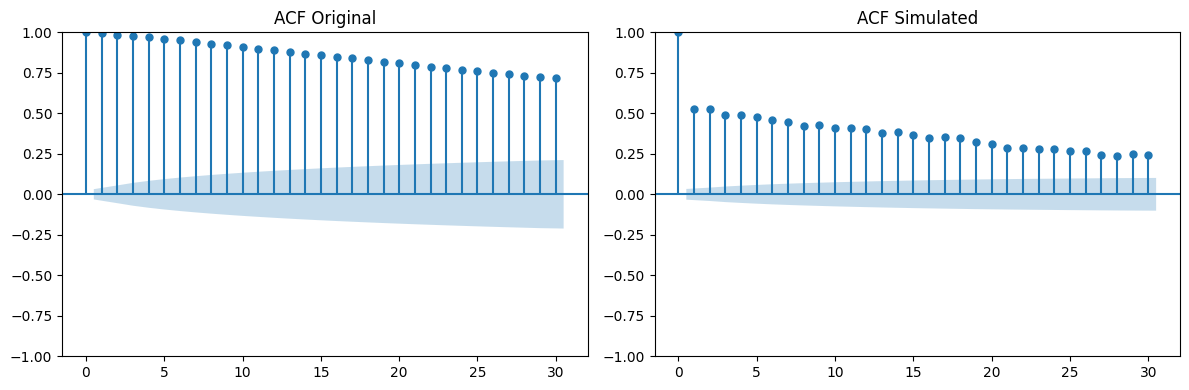

In [12]:
# Simulate common vol factor via Markov switching
transition_matrix = model_hmm.transmat_
regime_means = model_hmm.means_.flatten()
regime_stds = np.sqrt(model_hmm.covars_.flatten())

print(f"Low vol regime:  mean={regime_means[0]:.3f}, std={regime_stds[0]:.3f}, "
      f"avg duration={1/(1-transition_matrix[0,0]):.0f} days")
print(f"High vol regime: mean={regime_means[1]:.3f}, std={regime_stds[1]:.3f}, "
      f"avg duration={1/(1-transition_matrix[1,1]):.0f} days")

# Simulate
np.random.seed(42)
T_sim = len(Y_sim)
common_vol_sim = np.zeros(T_sim)
regime_sim = np.zeros(T_sim, dtype=int)

# Start in low vol regime
regime_sim[0] = 0
common_vol_sim[0] = regime_means[0]

for t in range(1, T_sim):
    # Transition
    regime_sim[t] = np.random.choice(2, p=transition_matrix[regime_sim[t-1]])
    # Draw from regime distribution
    common_vol_sim[t] = np.random.normal(
        regime_means[regime_sim[t]], 
        regime_stds[regime_sim[t]]
    )

# Plot to verify it looks like the original
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
pd.Series(common_vol_factor.flatten()).plot(
    ax=axes[0], title='Original Common Vol Factor', alpha=0.8)
pd.Series(common_vol_sim).plot(
    ax=axes[1], title='Simulated Common Vol Factor (Markov Switching)', 
    color='orange', alpha=0.8)
plt.tight_layout()
plt.show()

# Check ACF matches
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(common_vol_factor.flatten(), lags=30, ax=axes[0], 
         title='ACF Original')
plot_acf(common_vol_sim, lags=30, ax=axes[1], 
         title='ACF Simulated')
plt.tight_layout()
plt.show()

too noisy, add AR(1) as well

Regime 0: phi=0.979, sigma=0.122
Regime 1: phi=0.988, sigma=0.146


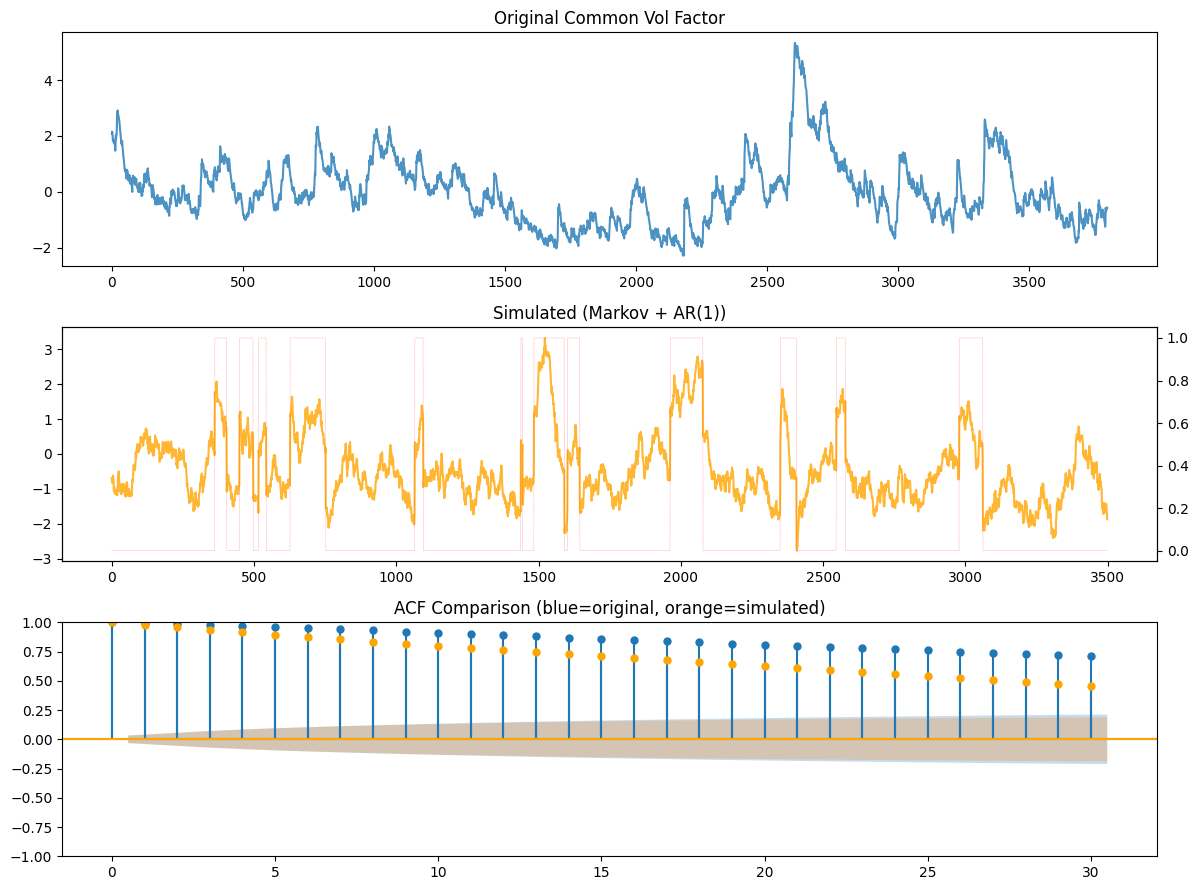


Original: mean=-0.000, std=1.169
Simulated: mean=-0.433, std=0.986


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg

common_vol_flat = common_vol_factor.flatten()
states_original = model_hmm.predict(common_vol_factor)

# 1. Fit AR(1) properly to residuals
ar_params = {}
for regime in [0, 1]:
    mask = states_original == regime
    # We only take segments where the regime is continuous to avoid "jumping"
    regime_data = common_vol_flat[mask]
    mu_r = regime_means[regime]
    
    # Calculate residuals from the regime mean
    residuals = regime_data - mu_r
    
    # Fit AR(1) on residuals WITHOUT a constant (trendless)
    # This captures the "stickiness" or momentum of the volatility
    ar_model = AutoReg(residuals, lags=1, trend='n').fit()
    
    ar_params[regime] = {
        'ar1': ar_model.params[0],
        'sigma': np.sqrt(ar_model.sigma2)
    }
    print(f"Regime {regime}: phi={ar_params[regime]['ar1']:.3f}, sigma={ar_params[regime]['sigma']:.3f}")

# 2. Simulate
np.random.seed(42)
common_vol_sim = np.zeros(T_sim)
regime_sim = np.zeros(T_sim, dtype=int)

# Initial state
regime_sim[0] = 0 
common_vol_sim[0] = regime_means[0]

for t in range(1, T_sim):
    # Transition the Hidden State
    prev_regime = regime_sim[t-1]
    curr_regime = np.random.choice(2, p=transition_matrix[prev_regime])
    regime_sim[t] = curr_regime
    
    # Parameters for the current regime
    p = ar_params[curr_regime]
    
    # Logic: New Value = Current Regime Mean + (Phi * Previous Deviation) + Noise
    prev_deviation = common_vol_sim[t-1] - regime_means[prev_regime]
    
    common_vol_sim[t] = (regime_means[curr_regime] + 
                         p['ar1'] * prev_deviation + 
                         np.random.normal(0, p['sigma']))
    


# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
pd.Series(common_vol_flat).plot(
    ax=axes[0], title='Original Common Vol Factor', alpha=0.8)

pd.Series(common_vol_sim).plot(
    ax=axes[1], title='Simulated (Markov + AR(1))', color='orange', alpha=0.8)

# Overlay regimes
ax2 = axes[1].twinx()
pd.Series(regime_sim.astype(float)).plot(
    ax=ax2, color='red', alpha=0.2, linewidth=0.5)

# ACF comparison
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(common_vol_flat, lags=30, ax=axes[2], alpha=0.05)
plot_acf(common_vol_sim, lags=30, ax=axes[2], alpha=0.05, color='orange')
axes[2].set_title('ACF Comparison (blue=original, orange=simulated)')
plt.tight_layout()
plt.show()

print(f"\nOriginal: mean={common_vol_flat.mean():.3f}, std={common_vol_flat.std():.3f}")
print(f"Simulated: mean={common_vol_sim.mean():.3f}, std={common_vol_sim.std():.3f}")

In [14]:
print("Original State Freq:", pd.Series(states_original).value_counts(normalize=True))
print("Simulated State Freq:", pd.Series(regime_sim).value_counts(normalize=True))

Original State Freq: 0    0.624112
1    0.375888
Name: proportion, dtype: float64
Simulated State Freq: 0    0.795714
1    0.204286
Name: proportion, dtype: float64


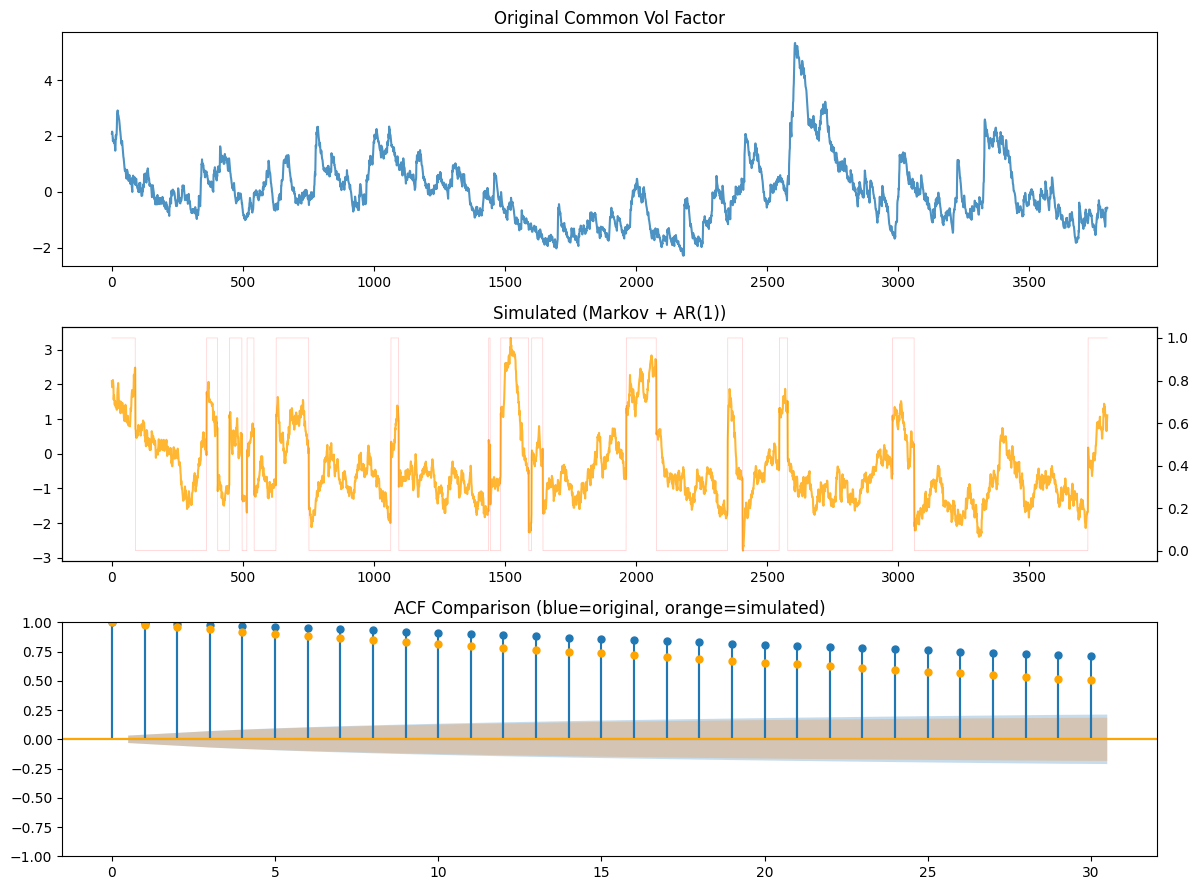


Original: mean=-0.000, std=1.169
Simulated: mean=-0.401, std=1.024


In [15]:
import numpy as np
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg

def fit_ar_on_blocks(data, states, regime, lags=1):
    """Fits AR(1) only on contiguous sequences of the same regime."""
    diff = np.diff(np.where(states == regime, 1, 0), prepend=0)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    
    # Collect all valid y_t, y_{t-1} pairs within the same regime block
    y, x = [], []
    for s, e in zip(starts, ends):
        block = data[s:e]
        if len(block) > lags:
            for i in range(lags, len(block)):
                y.append(block[i])
                x.append(block[i-1])
    
    # Simple OLS for the AR(1) coefficient phi on de-meaned data
    y, x = np.array(y), np.array(x)
    mu = np.mean(data[states == regime])
    y_dm, x_dm = y - mu, x - mu
    phi = np.sum(x_dm * y_dm) / np.sum(x_dm**2)
    sigma = np.std(y_dm - phi * x_dm)
    return phi, sigma

# --- APPLYING THE ROBUST FIT ---
ar_params = {}
for r in [0, 1]:
    phi, sigma = fit_ar_on_blocks(common_vol_flat, states_original, r)
    ar_params[r] = {'ar1': phi, 'sigma': sigma, 'mu': regime_means[r]}

# --- SIMULATION (Same logic, ensured mean stability) ---
np.random.seed(42)
common_vol_sim = np.zeros(len(common_vol_flat))
regime_sim = np.zeros(len(common_vol_flat), dtype=int)
regime_sim[0] = states_original[0]
common_vol_sim[0] = common_vol_flat[0]

for t in range(1, len(common_vol_flat)):
    r_prev = regime_sim[t-1]
    r_curr = np.random.choice(2, p=transition_matrix[r_prev])
    regime_sim[t] = r_curr
    
    p = ar_params[r_curr]
    dev_prev = common_vol_sim[t-1] - ar_params[r_prev]['mu']
    
    # Note: We cap phi at 0.99 to prevent explosion if data is near-unit-root
    phi_eff = min(p['ar1'], 0.99)
    common_vol_sim[t] = p['mu'] + phi_eff * dev_prev + np.random.normal(0, p['sigma'])


# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
pd.Series(common_vol_flat).plot(
    ax=axes[0], title='Original Common Vol Factor', alpha=0.8)

pd.Series(common_vol_sim).plot(
    ax=axes[1], title='Simulated (Markov + AR(1))', color='orange', alpha=0.8)

# Overlay regimes
ax2 = axes[1].twinx()
pd.Series(regime_sim.astype(float)).plot(
    ax=ax2, color='red', alpha=0.2, linewidth=0.5)

# ACF comparison
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(common_vol_flat, lags=30, ax=axes[2], alpha=0.05)
plot_acf(common_vol_sim, lags=30, ax=axes[2], alpha=0.05, color='orange')
axes[2].set_title('ACF Comparison (blue=original, orange=simulated)')
plt.tight_layout()
plt.show()

print(f"\nOriginal: mean={common_vol_flat.mean():.3f}, std={common_vol_flat.std():.3f}")
print(f"Simulated: mean={common_vol_sim.mean():.3f}, std={common_vol_sim.std():.3f}")

In [16]:
# Create a DataFrame to count transitions
df_trans = pd.DataFrame({'prev': states_original[:-1], 'curr': states_original[1:]})

# Calculate the transition probabilities (normalized by row)
emp_trans_matrix = pd.crosstab(df_trans['prev'], df_trans['curr'], normalize='index').values

print("Empirical Transition Matrix:\n", emp_trans_matrix)

Empirical Transition Matrix:
 [[0.99451477 0.00548523]
 [0.00980392 0.99019608]]


In [17]:
# --- SIMULATION WITH EMPIRICAL MATRIX ---
np.random.seed(42)
common_vol_sim = np.zeros(T_sim)
regime_sim = np.zeros(T_sim, dtype=int)

# Use the empirical matrix for transitions
trans_mat = emp_trans_matrix 

# Start in the same state as the original data
regime_sim[0] = states_original[0] 
common_vol_sim[0] = common_vol_flat[0]

for t in range(1, T_sim):
    prev_r = regime_sim[t-1]
    # Transition using the EMPIRICAL matrix
    curr_r = np.random.choice(2, p=trans_mat[prev_r])
    regime_sim[t] = curr_r
    
    p = ar_params[curr_r]
    # Use the residual logic from before
    prev_dev = common_vol_sim[t-1] - ar_params[prev_r]['mu']
    
    common_vol_sim[t] = (ar_params[curr_r]['mu'] + 
                         p['ar1'] * prev_dev + 
                         np.random.normal(0, p['sigma']))

# Final Verification
print("New Simulated State Freq:", pd.Series(regime_sim).value_counts(normalize=True))
print(f"Simulated Mean: {common_vol_sim.mean():.3f}")

New Simulated State Freq: 0    0.683714
1    0.316286
Name: proportion, dtype: float64
Simulated Mean: -0.217


In [18]:
# --- RECONSTRUCTION TEST ---
# Use the EXACT same states as the original to verify AR(1) parameters
regime_sim = states_original[:T_sim] 
common_vol_sim = np.zeros(T_sim)
common_vol_sim[0] = common_vol_flat[0]

for t in range(1, T_sim):
    r_prev = regime_sim[t-1]
    r_curr = regime_sim[t] # No randomness here, use historical state
    
    p = ar_params[r_curr]
    prev_dev = common_vol_sim[t-1] - ar_params[r_prev]['mu']
    
    common_vol_sim[t] = (ar_params[r_curr]['mu'] + 
                         p['ar1'] * prev_dev + 
                         np.random.normal(0, p['sigma']))

print(f"Reconstruction Mean: {common_vol_sim.mean():.3f}")
print(f"Reconstruction Std: {common_vol_sim.std():.3f}")

Reconstruction Mean: 0.068
Reconstruction Std: 1.325


In [19]:
# First check exactly what's in ar_params
for regime in [0, 1]:
    print(f"\nRegime {regime}:")
    for k, v in ar_params[regime].items():
        print(f"  {k}: {v:.4f}")

# The unconditional mean of AR(1) is: mu = const / (1 - ar1)
# NOT the regime mean from HMM directly
for regime in [0, 1]:
    p = ar_params[regime]
    mu_implied = p['const'] / (1 - p['ar1'])
    print(f"Regime {regime}: const={p['const']:.4f}, ar1={p['ar1']:.4f}, "
          f"implied_mu={mu_implied:.4f}, hmm_mean={regime_means[regime]:.4f}")


Regime 0:
  ar1: 0.9795
  sigma: 0.1180
  mu: -0.6890

Regime 1:
  ar1: 0.9893
  sigma: 0.1458
  mu: 1.1536


KeyError: 'const'

In [ ]:
# Redefine ar_params cleanly with correct mu
ar_params = {}
for regime in [0, 1]:
    mask = states_original == regime
    regime_data = common_vol_flat[mask]
    
    ar_model = AutoReg(regime_data, lags=1).fit()
    const = ar_model.params[0]
    ar1 = ar_model.params[1]
    mu = const / (1 - ar1)  # true unconditional mean
    sigma = np.sqrt(ar_model.sigma2)
    
    ar_params[regime] = {
        'const': const,
        'ar1': ar1,
        'mu': mu,
        'sigma': sigma
    }
    print(f"Regime {regime}: ar1={ar1:.4f}, mu={mu:.4f}, "
          f"hmm_mean={regime_means[regime]:.4f}, sigma={sigma:.4f}")

# Now simulate cleanly
np.random.seed(69)
common_vol_sim = np.zeros(T_sim)
regime_sim = np.zeros(T_sim, dtype=int)

regime_sim[0] = np.random.choice(2, p=[pi0, pi1])
common_vol_sim[0] = ar_params[regime_sim[0]]['mu']

for t in range(1, T_sim):
    regime_sim[t] = np.random.choice(2, p=transition_matrix[regime_sim[t-1]])
    r_curr = regime_sim[t]
    r_prev = regime_sim[t-1]
    p_curr = ar_params[r_curr]
    p_prev = ar_params[r_prev]
    
    # Mean-revert around current regime's unconditional mean
    prev_dev = common_vol_sim[t-1] - p_prev['mu']
    common_vol_sim[t] = (p_curr['mu'] + 
                         p_curr['ar1'] * prev_dev + 
                         np.random.normal(0, p_curr['sigma']))

print(f"\nSimulated mean: {common_vol_sim.mean():.3f} (target: {common_vol_flat.mean():.3f})")
print(f"Simulated std:  {common_vol_sim.std():.3f} (target: {common_vol_flat.std():.3f})")
print(f"State freq:\n{pd.Series(regime_sim).value_counts(normalize=True).sort_index()}")

Regime 0: ar1=0.9778, mu=-0.4945, hmm_mean=-4.7226, sigma=0.1488
Regime 1: ar1=0.9773, mu=1.4585, hmm_mean=-4.2497, sigma=0.2290

Simulated mean: 0.027 (target: -0.000)
Simulated std:  1.159 (target: 1.169)
State freq:
0    0.721143
1    0.278857
Name: proportion, dtype: float64


In [ ]:
Nästa steg: skew!

SyntaxError: invalid syntax (507249967.py, line 1)